# Import libraries

In [1]:
import os
import zipfile
import pandas as pd
import numpy as np
from copy import deepcopy
from sklearn.model_selection import KFold, train_test_split
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from catboost import CatBoostRegressor
from kaggle.api.kaggle_api_extended import KaggleApi

from kvbiii_plots.eda.categorical_plots import CategoricalPlots
categorical_plots = CategoricalPlots()
from kvbiii_plots.eda.continuous_plots import ContinuousPlots
continuous_plots = ContinuousPlots()
from kvbiii_plots.ml.optuna_plots import OptunaPlots
optuna_plots = OptunaPlots()
from kvbiii_plots.evaluation.regression_plots import RegressionPlots
regression_plots = RegressionPlots()
from kvbiii_plots.ml.other_plots import OtherPlots
other_plots = OtherPlots()

from kvbiii_ml.data_processing.eda.data_analysis import DataAnalyzer
data_analyzer = DataAnalyzer()
from kvbiii_ml.data_processing.eda.data_cleaning import DataCleaner
data_cleaner = DataCleaner()
from kvbiii_ml.data_processing.eda.data_transformation import DataTransformer
data_transformer = DataTransformer()
from kvbiii_ml.data_processing.feature_engineering.cross_encoding import CrossFeatureGenerator
from kvbiii_ml.data_processing.feature_engineering.count_encoding import CountEncodingFeatureGenerator
from kvbiii_ml.data_processing.feature_engineering.target_encoding import TargetEncodingFeatureGenerator
from kvbiii_ml.data_processing.feature_engineering.feature_generation_pipeline import FeatureGenerationPipeline
from kvbiii_ml.modeling.training.cross_validation import CrossValidationTrainer
from kvbiii_ml.modeling.training.ensemble_model import EnsembleModel
from kvbiii_ml.data_processing.feature_selection.shap_rfe import ShapRecursiveFeatureElimination
from kvbiii_ml.modeling.optimization.hyperparameter_tuning import RandomSearchCV
from kvbiii_ml.modeling.optimization.ensemble_weights_tuner import EnsembleWeightTunerCV
from kvbiii_ml.evaluation.metrics import METRICS
from kvbiii_ml.evaluation.generate_reports import regression_results

SEED = 17
PROBLEM_TYPE = "regression"
METRIC_NAME = "RMSE"
CV = KFold(n_splits=5, shuffle=True, random_state=SEED)
N_TRIALS = 100

cross_validation_trainer = CrossValidationTrainer(metric_name = METRIC_NAME, problem_type=PROBLEM_TYPE, cv = CV, verbose=False)

# Load dataset

In [ ]:
api = KaggleApi()
api.authenticate()
slug, path = "playground-series-s5e10", "input"
os.makedirs(path, exist_ok=True)
api.competition_download_files(slug, path=path)
zip_file = os.path.join(path, slug.split("/")[-1] + ".zip")
with zipfile.ZipFile(zip_file) as z:
    z.extractall(path)
train_data, test_data = [
    pd.read_csv(os.path.join(path, f"{name}.csv"), index_col="id")
    for name in ("train", "test")
]
os.remove(zip_file)
target_feature = "accident_risk"
# train_data = train_data[:1000]
train_data

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
id,,,,,,,,,,,,,
0,urban,2,0.06,35,daylight,rainy,False,True,afternoon,False,True,1,0.13
1,urban,4,0.99,35,daylight,clear,True,False,evening,True,True,0,0.35
2,rural,4,0.63,70,dim,clear,False,True,morning,True,False,2,0.30
3,highway,4,0.07,35,dim,rainy,True,True,morning,False,False,1,0.21
4,rural,1,0.58,60,daylight,foggy,False,False,evening,True,False,1,0.56
...,...,...,...,...,...,...,...,...,...,...,...,...,...
517749,highway,4,0.10,70,daylight,foggy,True,True,afternoon,False,False,2,0.32
517750,rural,4,0.47,35,daylight,rainy,True,True,morning,False,False,1,0.26
517751,urban,4,0.62,25,daylight,foggy,False,False,afternoon,False,True,0,0.19


In [3]:
data_analyzer.base_information(train_data)

,Feature,dtypes,Number of missing values,Percentage of missing values,Unique values,Count
0,road_type,object,0,0.00%,3,"517,754"
1,num_lanes,int64,0,0.00%,4,"517,754"
2,curvature,float64,0,0.00%,261,"517,754"
3,speed_limit,int64,0,0.00%,5,"517,754"
4,lighting,object,0,0.00%,3,"517,754"
5,weather,object,0,0.00%,3,"517,754"
6,road_signs_present,bool,0,0.00%,2,"517,754"
7,public_road,bool,0,0.00%,2,"517,754"
8,time_of_day,object,0,0.00%,3,"517,754"
9,holiday,bool,0,0.00%,2,"517,754"


In [4]:
data_analyzer.base_information(train_data)

,Feature,dtypes,Number of missing values,Percentage of missing values,Unique values,Count
0,road_type,object,0,0.00%,3,"517,754"
1,num_lanes,int64,0,0.00%,4,"517,754"
2,curvature,float64,0,0.00%,261,"517,754"
3,speed_limit,int64,0,0.00%,5,"517,754"
4,lighting,object,0,0.00%,3,"517,754"
5,weather,object,0,0.00%,3,"517,754"
6,road_signs_present,bool,0,0.00%,2,"517,754"
7,public_road,bool,0,0.00%,2,"517,754"
8,time_of_day,object,0,0.00%,3,"517,754"
9,holiday,bool,0,0.00%,2,"517,754"


# Initial features cleaning

In [5]:
train_data = data_cleaner.initial_features_removal(train_data)


Number of features after removal: 13. Removed 0 features.


## ❌ Dropped Features

Remove those features that have at least threshold (default 0.99) of values in one category (are extremely unbalanced)

In [6]:
categorical_features = data_analyzer.get_categorical_features(train_data, unique_threshold=100)
train_data = data_cleaner.drop_highly_skewed_categorical_features(train_data, features_to_investigate=train_data.drop(columns=[target_feature]).columns.tolist(), threshold=0.99)
categorical_features = data_analyzer.get_categorical_features(train_data, unique_threshold=100)

## Duplicates

In [7]:
print(f"Number of duplicated rows: {train_data.duplicated().sum()}")
train_data = train_data.drop_duplicates(keep='last').reset_index(drop=True)
print(f"Number of duplicated rows after removal: {train_data.duplicated().sum()}")

Number of duplicated rows: 656
Number of duplicated rows after removal: 0


# Missing values

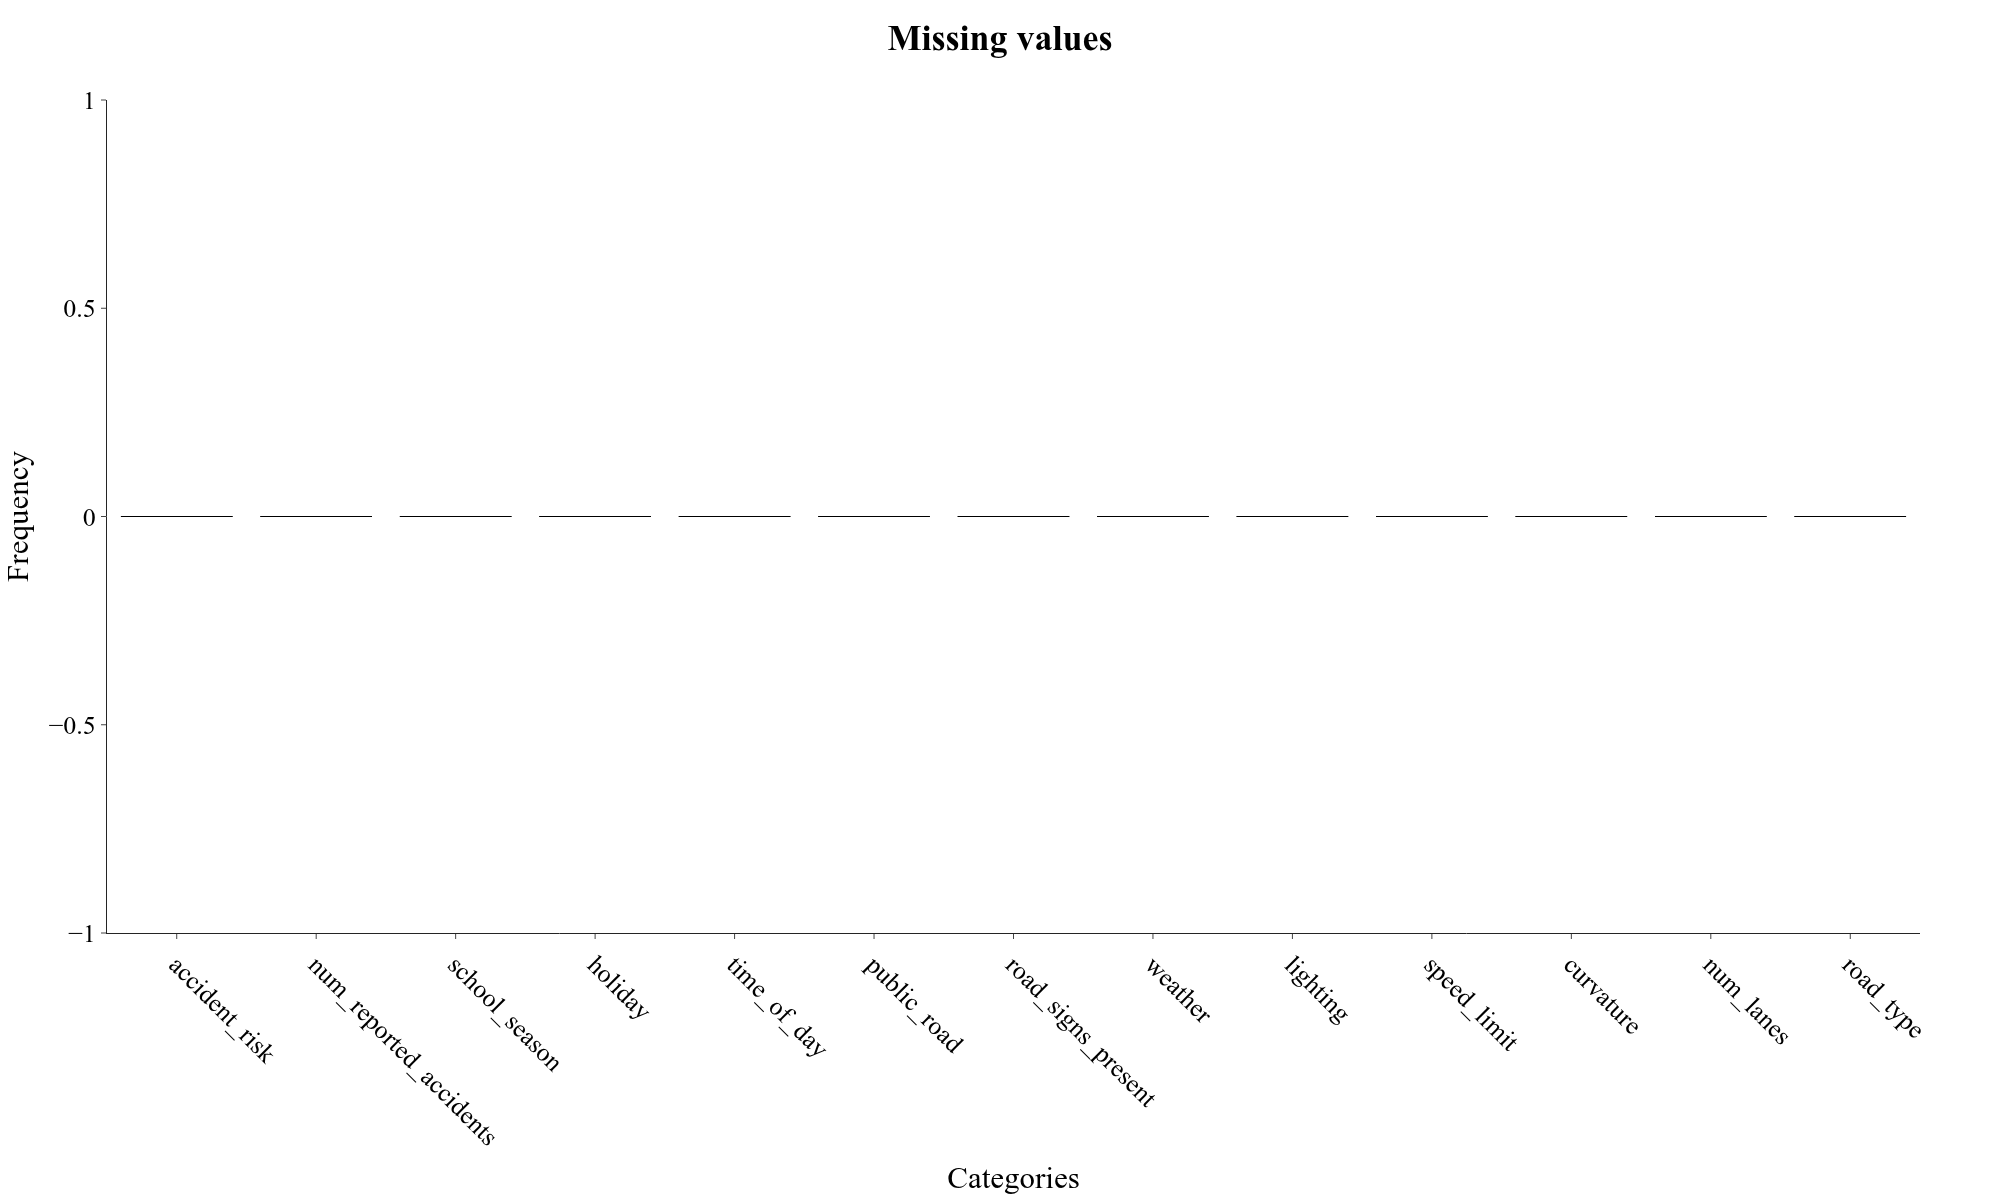

In [8]:
categorical_plots.barplot(train_data.isna().sum(), plot_title=f"Missing values", top_n=20, show_other=False, tickangle=45, width=2000, height=1200)

# Features exploration

In [9]:
features = train_data.columns.tolist()
features = [(feature, train_data[feature].dtype) for feature in features]
for feature, dtype in features:
    print(f"- {feature} ({dtype})", end="\n")

- road_type (object)
- num_lanes (int64)
- curvature (float64)
- speed_limit (int64)
- lighting (object)
- weather (object)
- road_signs_present (bool)
- public_road (bool)
- time_of_day (object)
- holiday (bool)
- school_season (bool)
- num_reported_accidents (int64)
- accident_risk (float64)


## Dataset Features Description

- `accident_risk` (float64): A numerical score representing the predicted or calculated risk of accidents occurring on this road segment - **target variable**.
- `road_type` (object): The classification or category of road (e.g., highway, arterial, residential). Different road types have varying traffic patterns and safety characteristics.
- `num_lanes` (int64): The total number of driving lanes available on the road segment. More lanes typically indicate higher traffic capacity and potentially different accident patterns.
- `curvature` (float64): A numerical measure of how curved or winding the road segment is. Higher curvature values indicate sharper turns which may increase accident risk.
- `speed_limit` (int64): The maximum legal driving speed allowed on the road segment in appropriate units. Higher speed limits may correlate with different accident severity and frequency.
- `lighting` (object): The type of lighting conditions present on the road (e.g., streetlights, no lighting, daylight). Poor lighting conditions can significantly impact driving safety.
- `weather` (object): The prevailing weather conditions during the observation period. Adverse weather like rain, snow, or fog typically increases accident risk.
- `road_signs_present` (bool): Indicates whether traffic signs are present on the road segment. Proper signage helps guide drivers and may reduce accident likelihood.
- `public_road` (bool): Distinguishes between public roads (maintained by government) and private roads. Public roads may have different safety standards and maintenance levels.
- `time_of_day` (object): The time period when observations were made (e.g., morning, afternoon, night). Traffic patterns and driver alertness vary throughout the day.
- `holiday` (bool): Indicates whether the observation was made during a holiday period. Holiday traffic patterns often differ from regular days and may affect accident rates.
- `school_season` (bool): Indicates whether schools are in session during the observation period. School zones and increased pedestrian traffic can impact road safety.
- `num_reported_accidents` (int64): The number of accidents that have been officially reported on this road segment. This provides historical context for accident frequency.

## `accident_risk`

`accident_risk` (float64) - A numerical score representing the predicted or calculated risk of accidents occurring on this road segment - **target variable**.

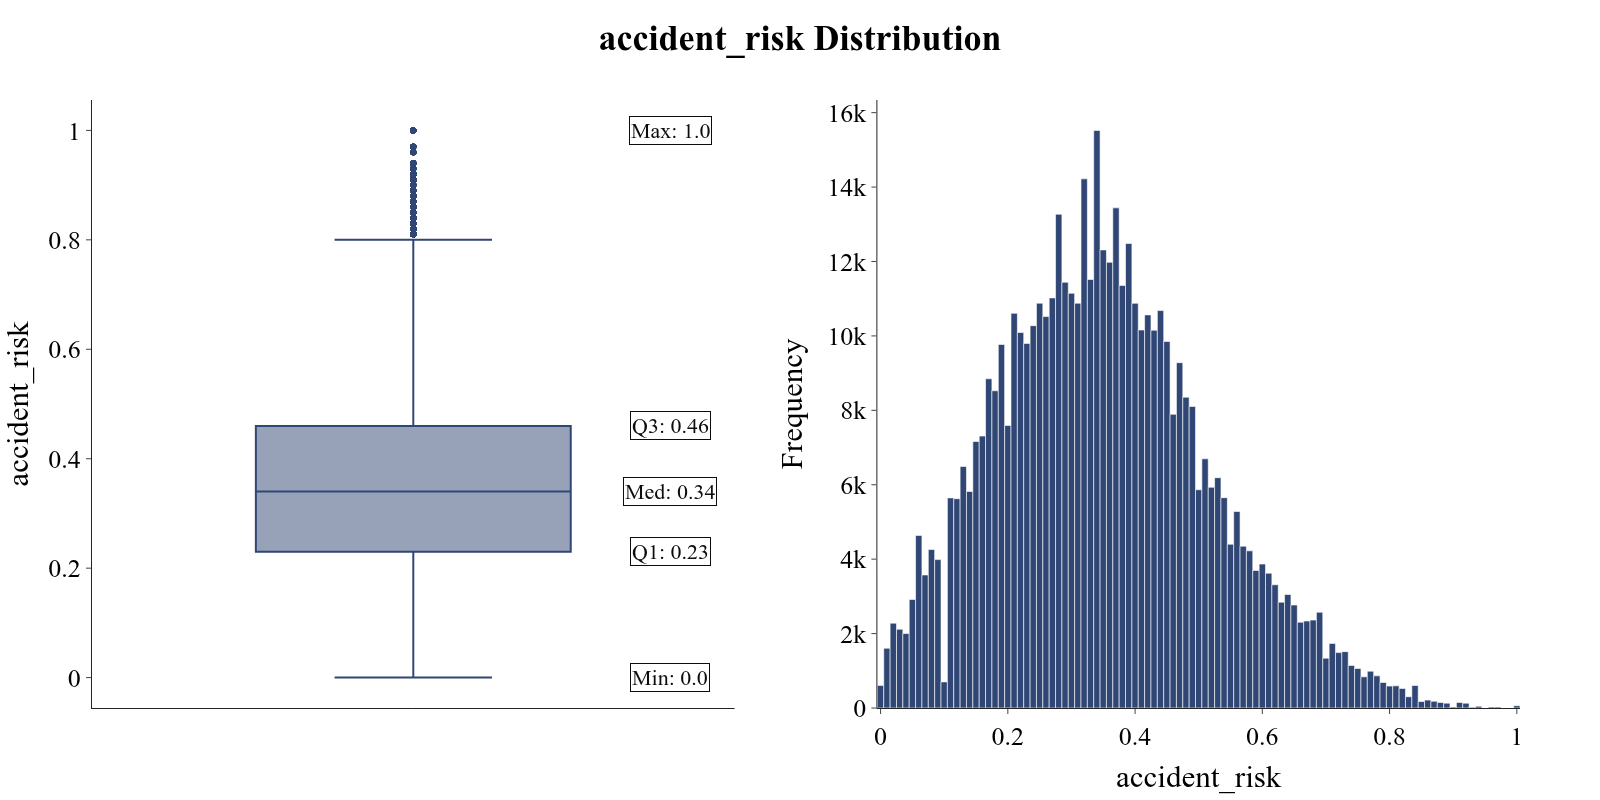

,Count,Mean,Std,Min,5%,Q1,Median,Q3,95%,Max,variance,skewness,kurtosis,Missing,Missing (%)
accident_risk,"517,098",0.35,0.17,0.00,0.09,0.23,0.34,0.46,0.65,1.00,0.03,0.38,-0.08,0,0.00%


In [10]:
continuous_plots.histogram_and_box_plot(train_data[target_feature], plot_title=f"{target_feature} Distribution")
data_analyzer.describe_numerical_feature(train_data, target_feature)

**Notes:**

**Conclusion:**

## `road_type`

`road_type` (object) - The classification or category of road (e.g., highway, arterial, residential). Different road types have varying traffic patterns and safety characteristics.

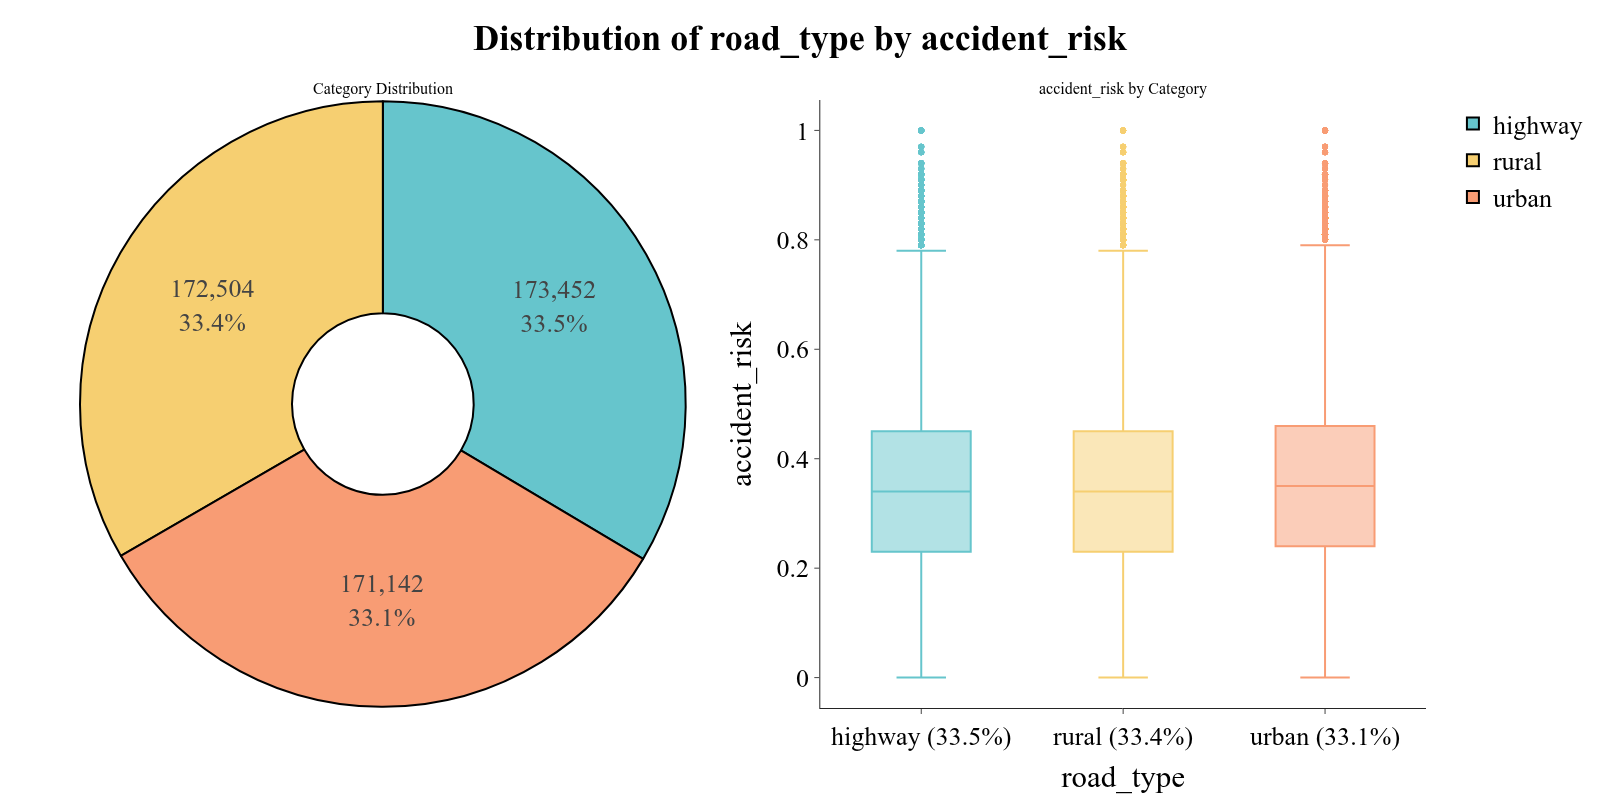

,Category,Count,Percentage (%)
0,highway,"173,452",33.54%
1,rural,"172,504",33.36%
2,urban,"171,142",33.10%


In [11]:
feature = "road_type"
categorical_plots.pie_boxplot_by_categorical(train_data, feature, target_feature, plot_title=f"Distribution of {feature} by {target_feature}")
data_analyzer.describe_categorical_feature(train_data, feature)

**Notes:**

**Conclusion:**

## `num_lanes`

`num_lanes` (int64) - The total number of driving lanes available on the road segment. More lanes typically indicate higher traffic capacity and potentially different accident patterns.

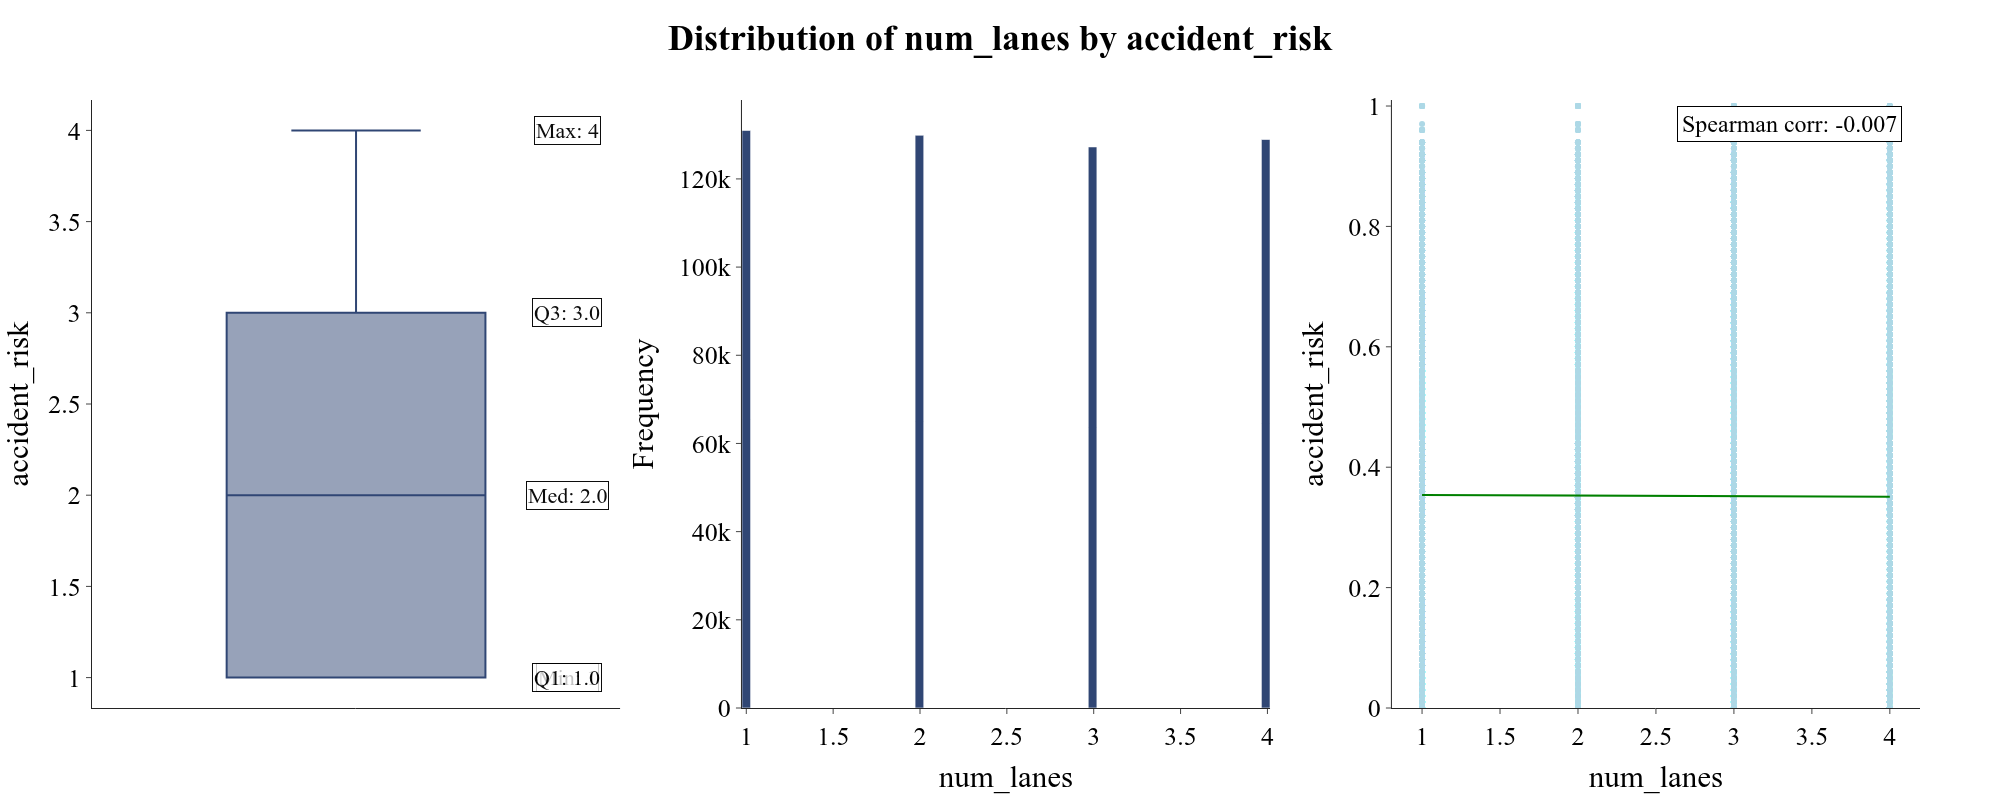

,Count,Mean,Std,Min,5%,Q1,Median,Q3,95%,Max,variance,skewness,kurtosis,Missing,Missing (%)
num_lanes,"517,098",2.49,1.12,1.00,1.00,1.00,2.00,3.00,4.00,4.00,1.26,0.01,-1.37,0,0.00%


In [12]:
feature = "num_lanes"
continuous_plots.histogram_boxplot_linear_regression(train_data, feature, target_feature, plot_title=f"Distribution of {feature} by {target_feature}")
data_analyzer.describe_numerical_feature(train_data, feature)

**Notes:**

**Conclusion:**

## `curvature`

`curvature` (float64) - A numerical measure of how curved or winding the road segment is. Higher curvature values indicate sharper turns which may increase accident risk.

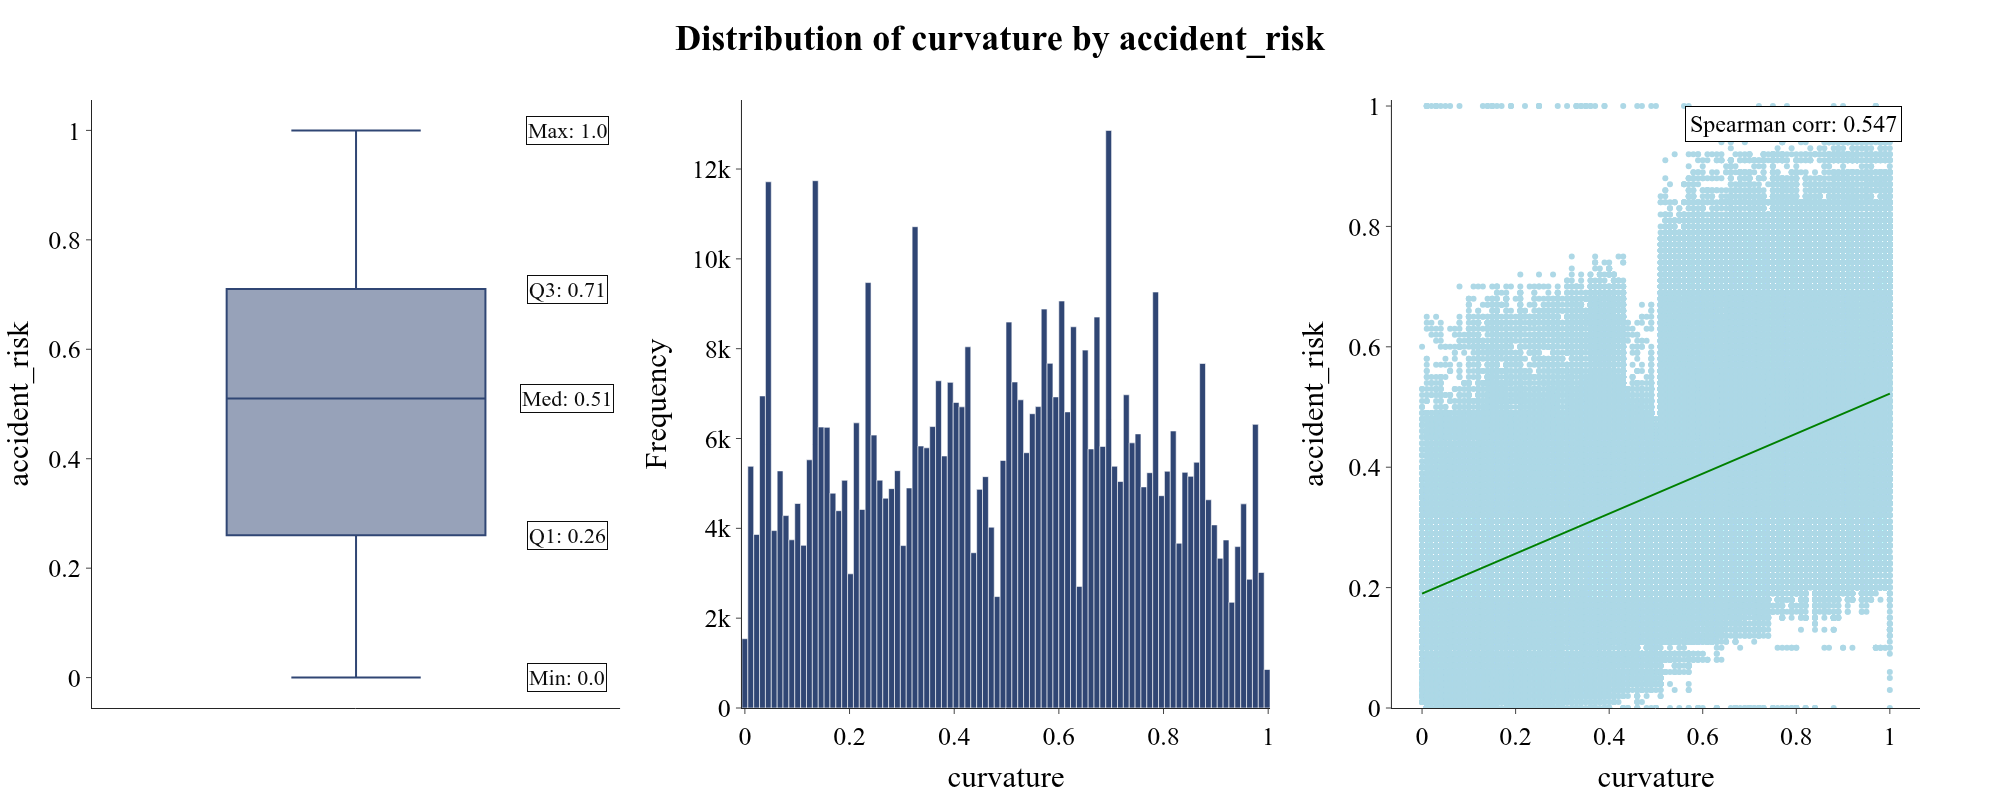

,Count,Mean,Std,Min,5%,Q1,Median,Q3,95%,Max,variance,skewness,kurtosis,Missing,Missing (%)
curvature,"517,098",0.49,0.27,0.00,0.05,0.26,0.51,0.71,0.92,1.00,0.07,-0.04,-1.10,0,0.00%


In [13]:
feature = "curvature"
continuous_plots.histogram_boxplot_linear_regression(train_data, feature, target_feature, plot_title=f"Distribution of {feature} by {target_feature}")
data_analyzer.describe_numerical_feature(train_data, feature)

**Notes:**

**Conclusion:**

## `speed_limit`

`speed_limit` (int64) - The maximum legal driving speed allowed on the road segment in appropriate units. Higher speed limits may correlate with different accident severity and frequency.

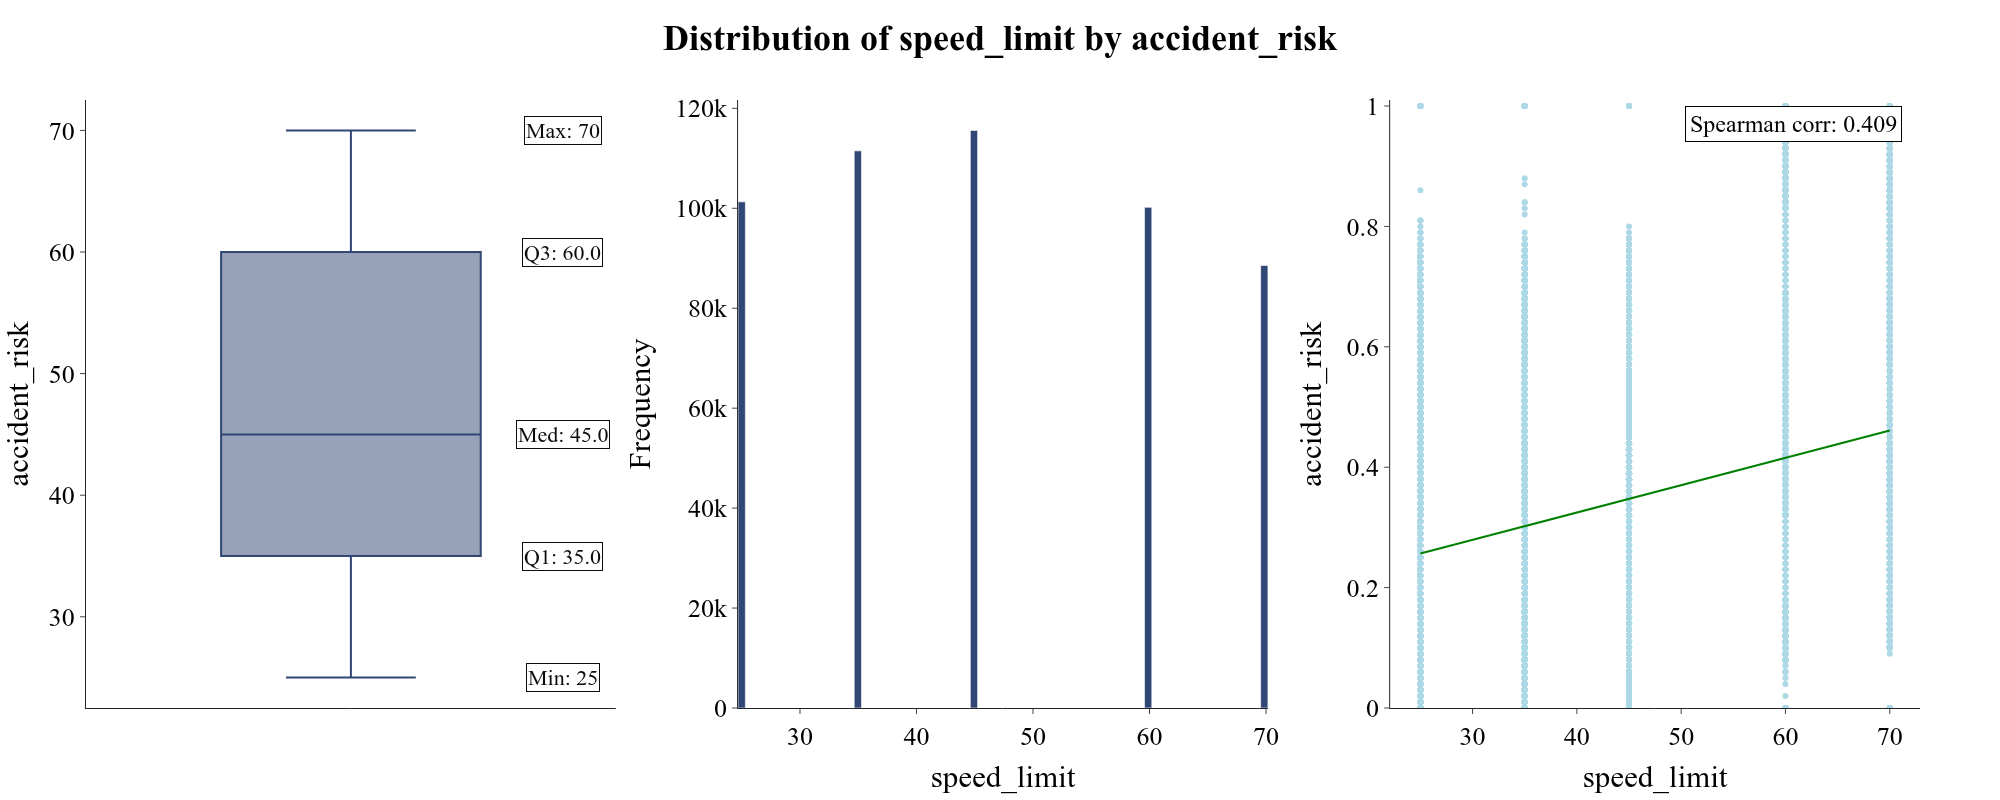

,Count,Mean,Std,Min,5%,Q1,Median,Q3,95%,Max,variance,skewness,kurtosis,Missing,Missing (%)
speed_limit,"517,098",46.11,15.79,25.00,25.00,35.00,45.00,60.00,70.00,70.00,249.29,0.18,-1.31,0,0.00%


In [14]:
feature = "speed_limit"
continuous_plots.histogram_boxplot_linear_regression(train_data, feature, target_feature, plot_title=f"Distribution of {feature} by {target_feature}")
data_analyzer.describe_numerical_feature(train_data, feature)

**Notes:**

**Conclusion:**

## `lighting`

`lighting` (object) - The type of lighting conditions present on the road (e.g., streetlights, no lighting, daylight). Poor lighting conditions can significantly impact driving safety.

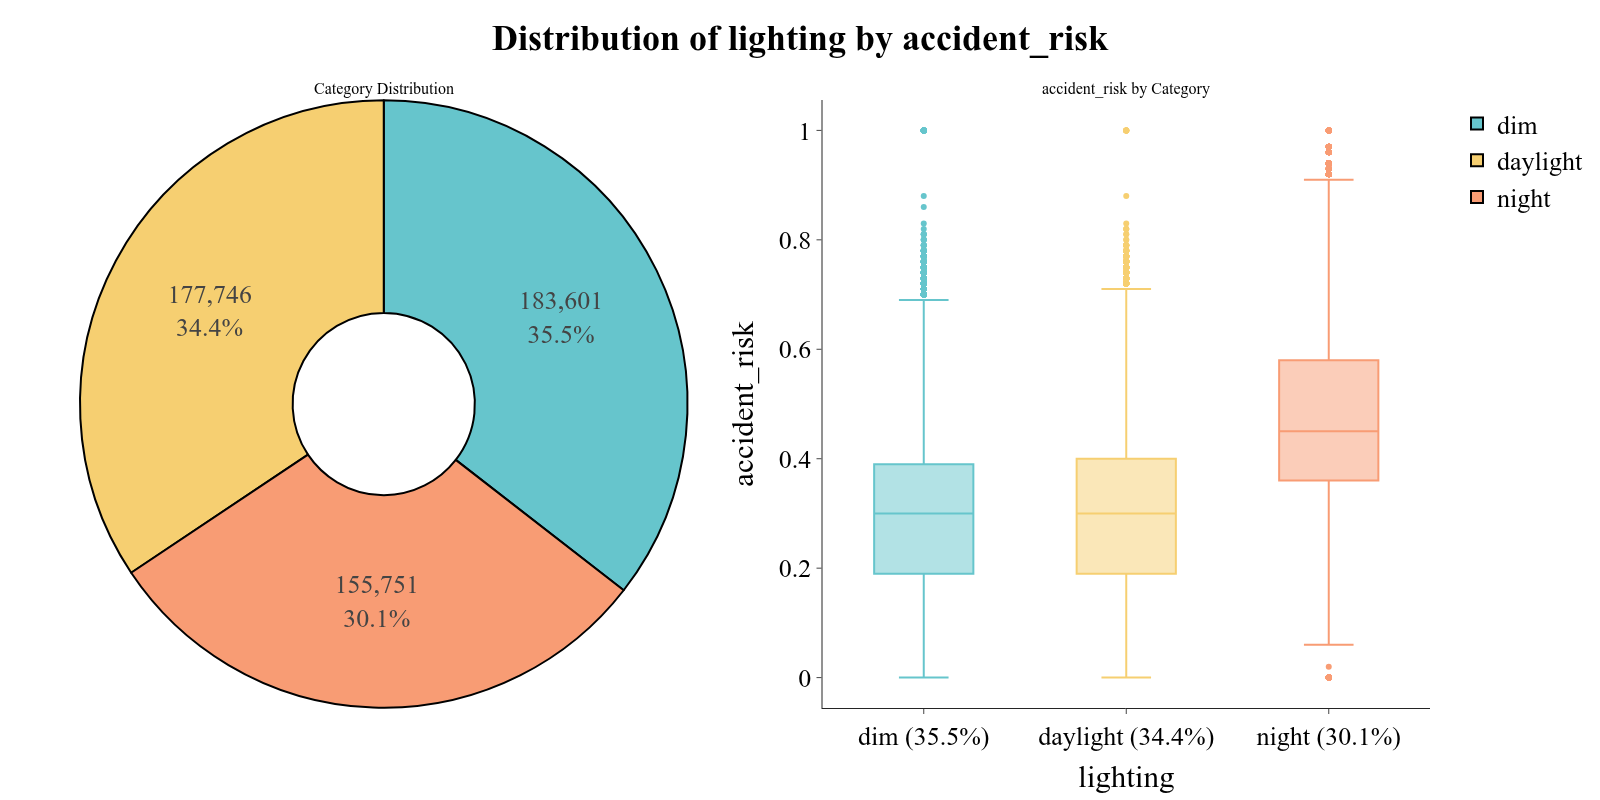

,Category,Count,Percentage (%)
0,dim,"183,601",35.51%
1,daylight,"177,746",34.37%
2,night,"155,751",30.12%


In [15]:
feature = "lighting"
categorical_plots.pie_boxplot_by_categorical(train_data, feature, target_feature, plot_title=f"Distribution of {feature} by {target_feature}")
data_analyzer.describe_categorical_feature(train_data, feature)

**Notes:**

**Conclusion:**

## `weather`

`weather` (object) - The prevailing weather conditions during the observation period. Adverse weather like rain, snow, or fog typically increases accident risk.

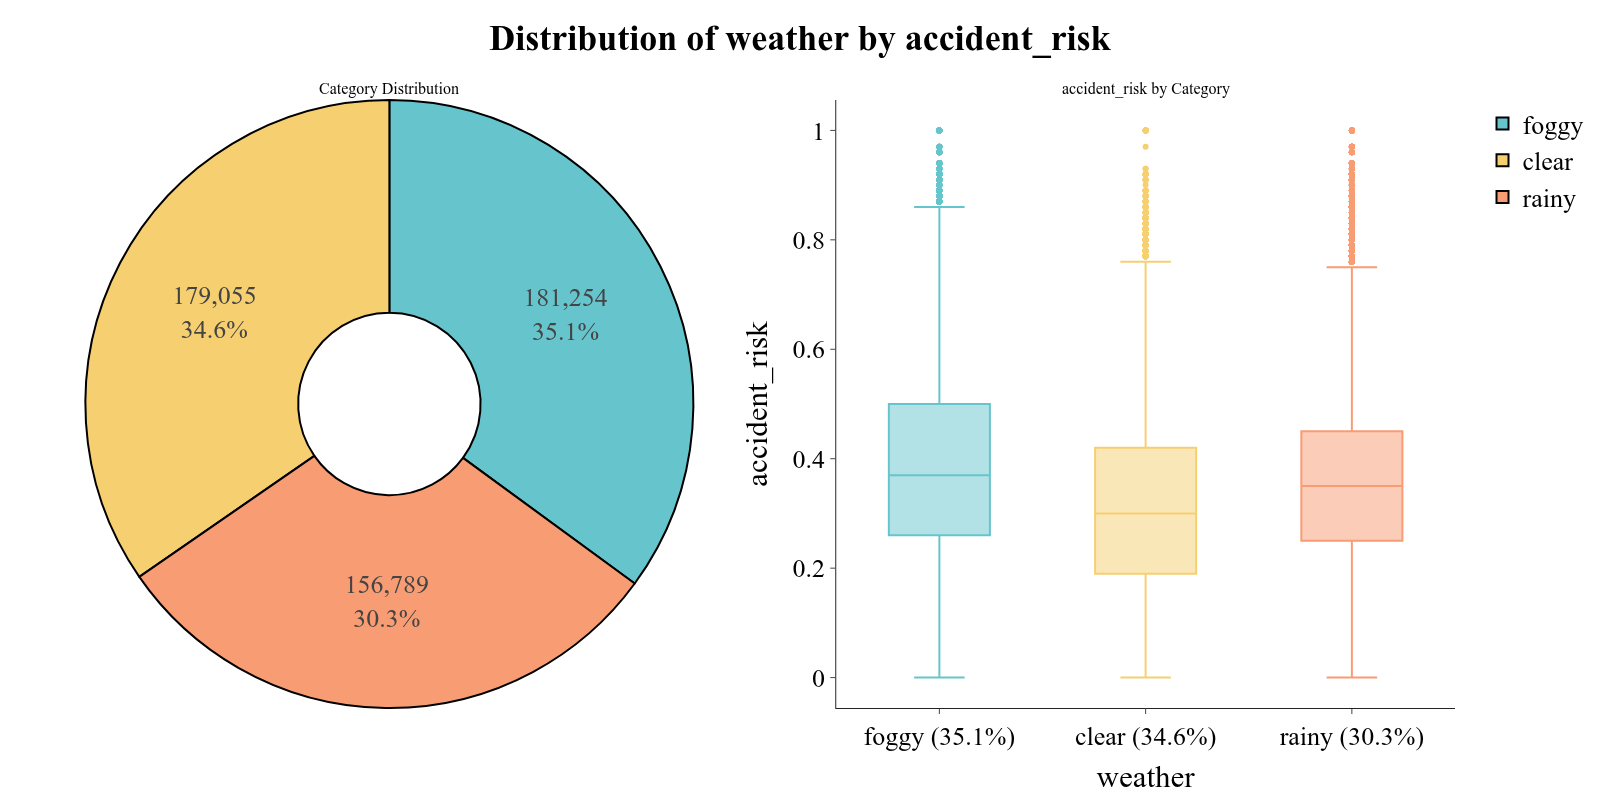

,Category,Count,Percentage (%)
0,foggy,"181,254",35.05%
1,clear,"179,055",34.63%
2,rainy,"156,789",30.32%


In [16]:
feature = "weather"
categorical_plots.pie_boxplot_by_categorical(train_data, feature, target_feature, plot_title=f"Distribution of {feature} by {target_feature}")
data_analyzer.describe_categorical_feature(train_data, feature)

**Notes:**

**Conclusion:**

## `road_signs_present`

`road_signs_present` (bool) - Indicates whether traffic signs are present on the road segment. Proper signage helps guide drivers and may reduce accident likelihood.

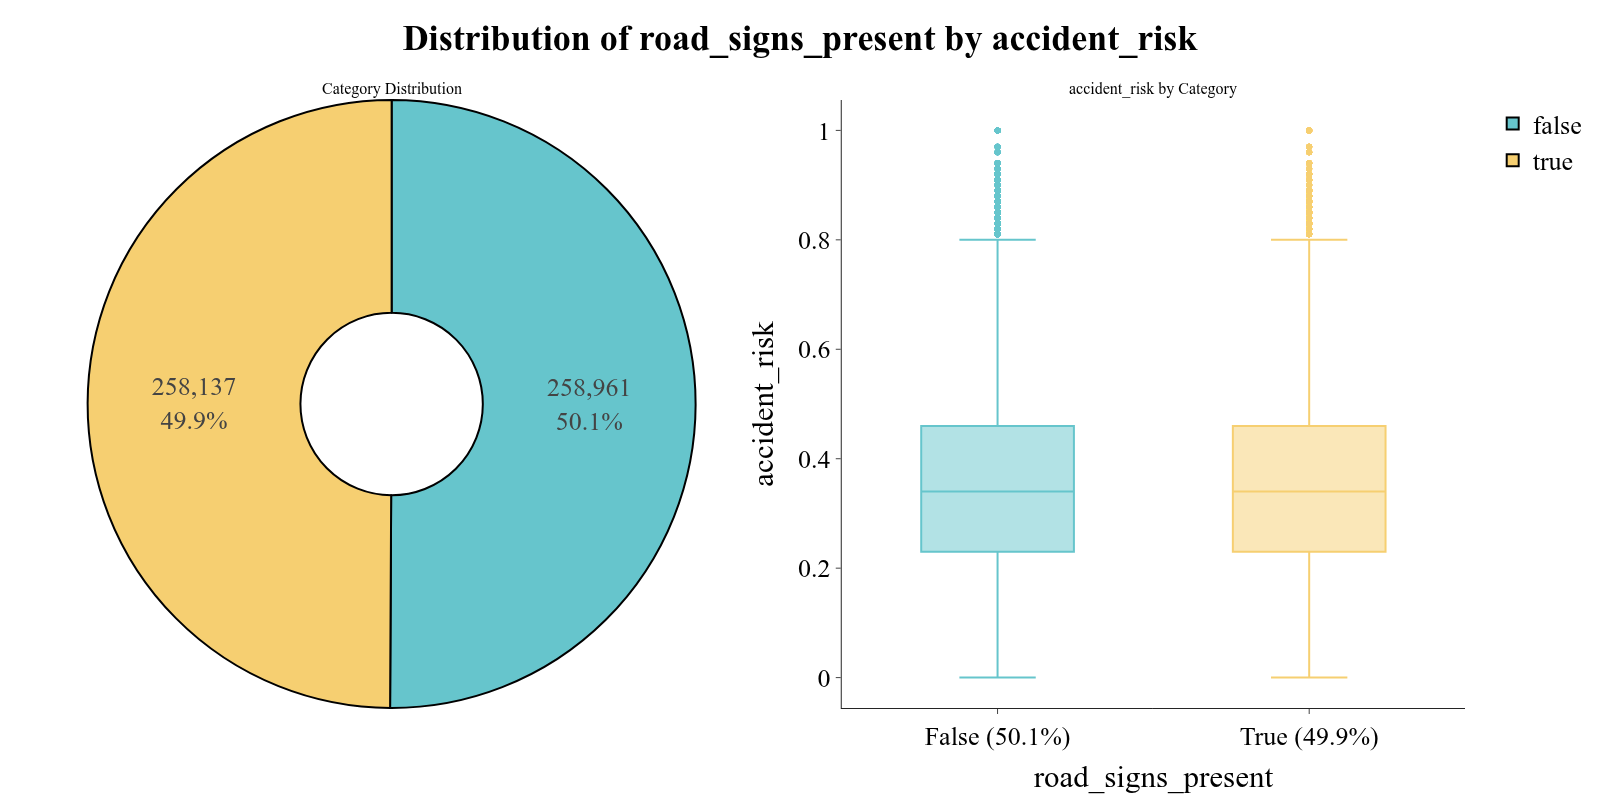

,Category,Count,Percentage (%)
0,False,"258,961",50.08%
1,True,"258,137",49.92%


In [17]:
feature = "road_signs_present"
categorical_plots.pie_boxplot_by_categorical(train_data, feature, target_feature, plot_title=f"Distribution of {feature} by {target_feature}")
data_analyzer.describe_categorical_feature(train_data, feature)

**Notes:**

**Conclusion:**

## `public_road`

`public_road` (bool) - Distinguishes between public roads (maintained by government) and private roads. Public roads may have different safety standards and maintenance levels.

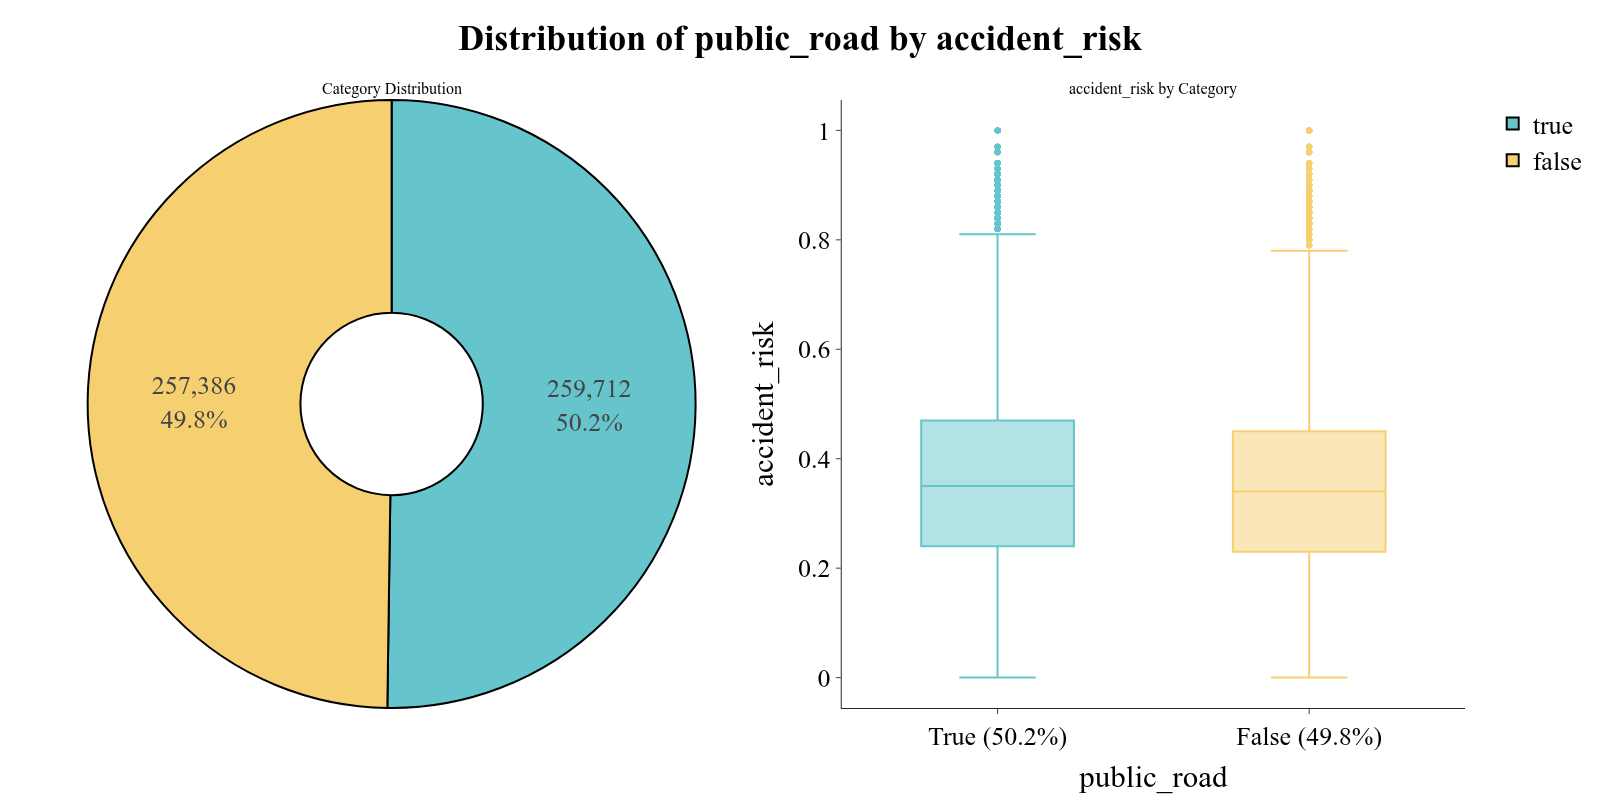

,Category,Count,Percentage (%)
0,True,"259,712",50.22%
1,False,"257,386",49.78%


In [18]:
feature = "public_road"
categorical_plots.pie_boxplot_by_categorical(train_data, feature, target_feature, plot_title=f"Distribution of {feature} by {target_feature}")
data_analyzer.describe_categorical_feature(train_data, feature)

**Notes:**

**Conclusion:**

## `time_of_day`

`time_of_day` (object) - The time period when observations were made (e.g., morning, afternoon, night). Traffic patterns and driver alertness vary throughout the day.

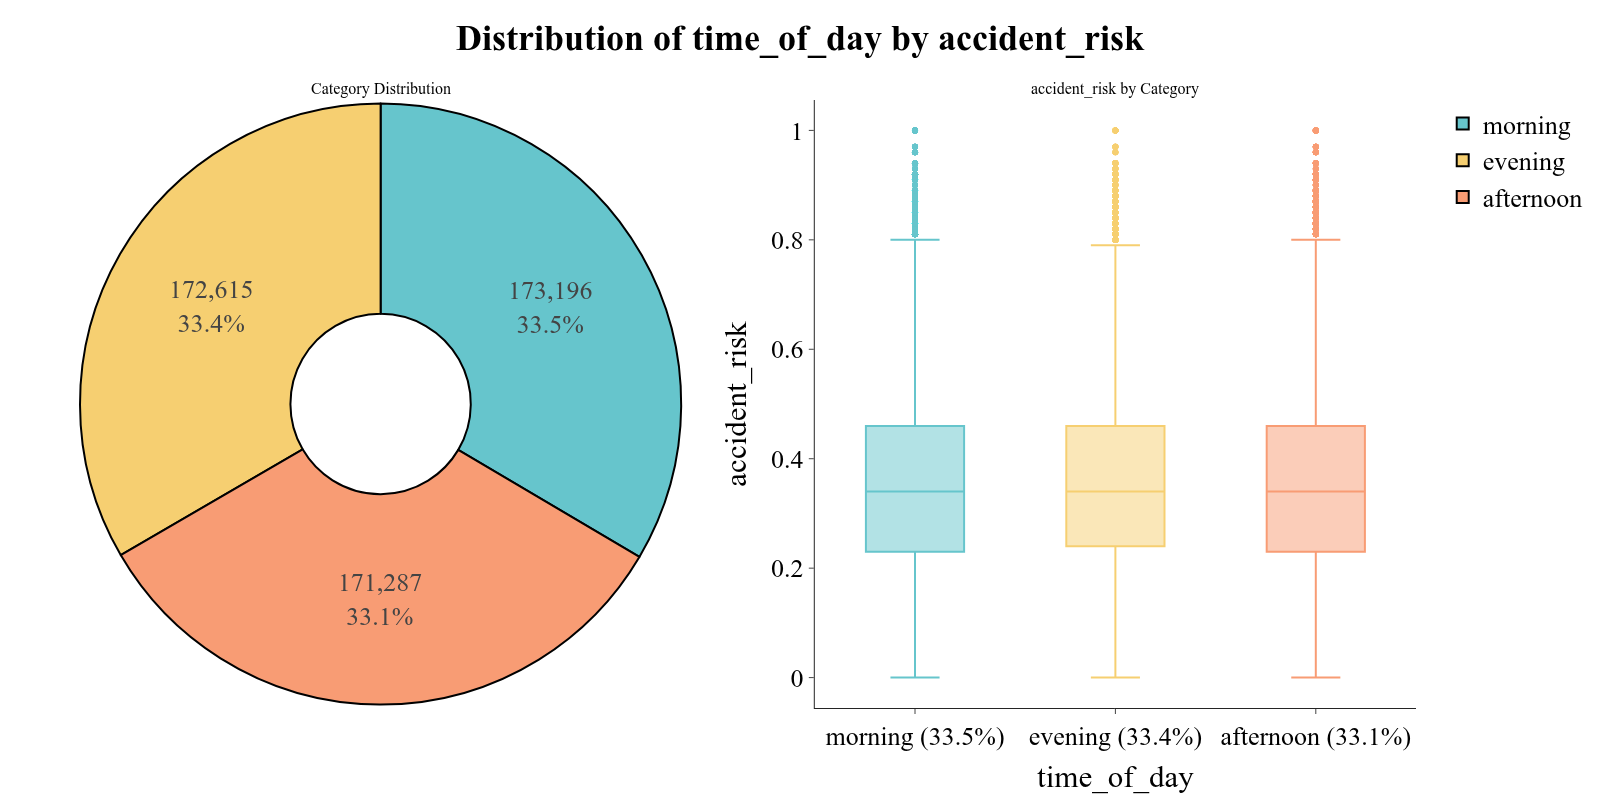

,Category,Count,Percentage (%)
0,morning,"173,196",33.49%
1,evening,"172,615",33.38%
2,afternoon,"171,287",33.12%


In [19]:
feature = "time_of_day"
categorical_plots.pie_boxplot_by_categorical(train_data, feature, target_feature, plot_title=f"Distribution of {feature} by {target_feature}")
data_analyzer.describe_categorical_feature(train_data, feature)

**Notes:**

**Conclusion:**

## `holiday`

`holiday` (bool) - Indicates whether the observation was made during a holiday period. Holiday traffic patterns often differ from regular days and may affect accident rates.

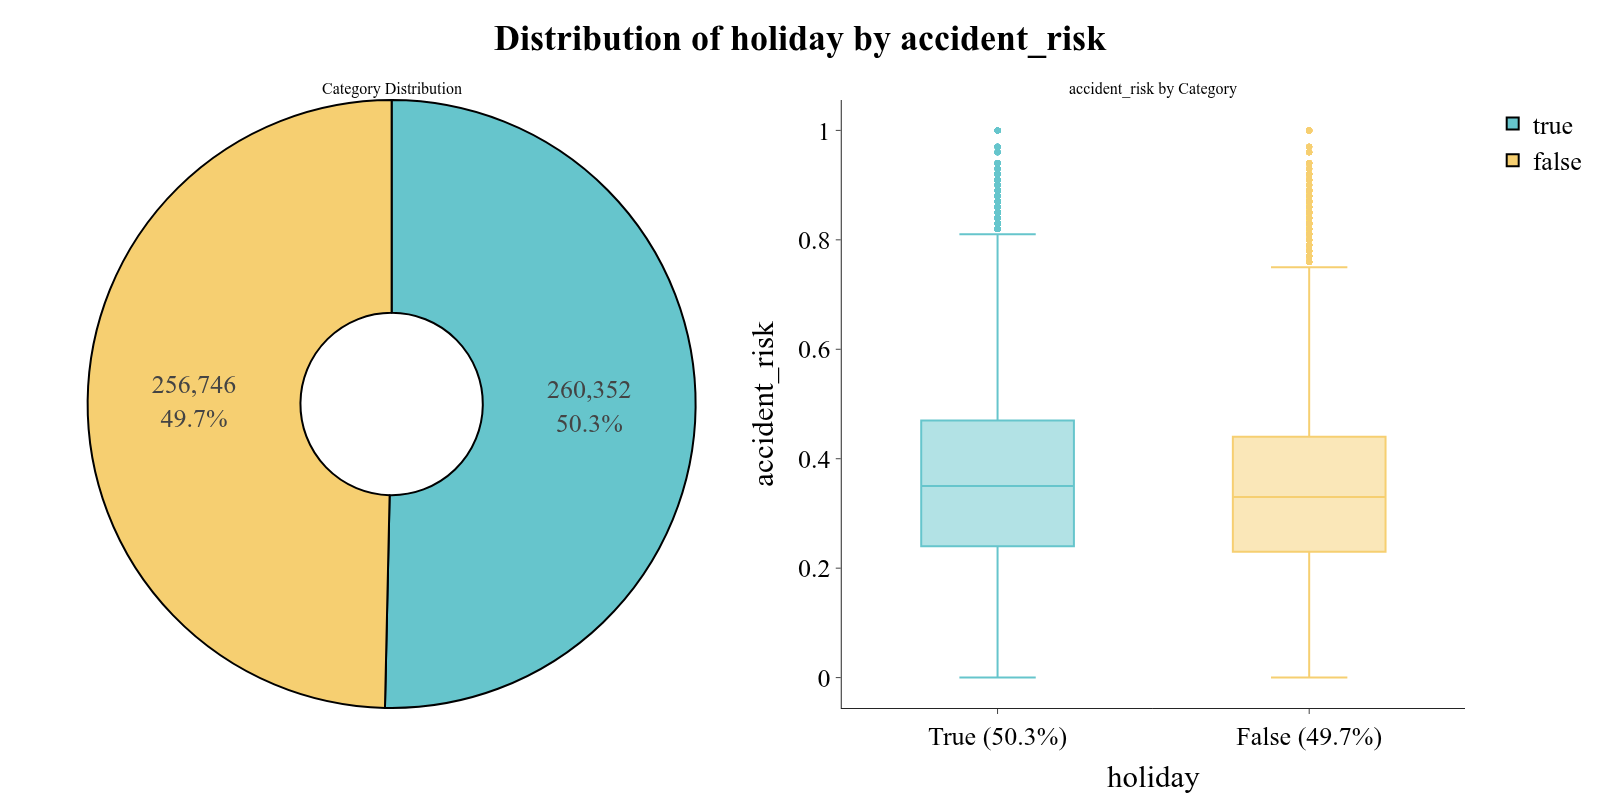

,Category,Count,Percentage (%)
0,True,"260,352",50.35%
1,False,"256,746",49.65%


In [20]:
feature = "holiday"
categorical_plots.pie_boxplot_by_categorical(train_data, feature, target_feature, plot_title=f"Distribution of {feature} by {target_feature}")
data_analyzer.describe_categorical_feature(train_data, feature)

**Notes:**

**Conclusion:**

## `school_season`

`school_season` (bool) - Indicates whether schools are in session during the observation period. School zones and increased pedestrian traffic can impact road safety.

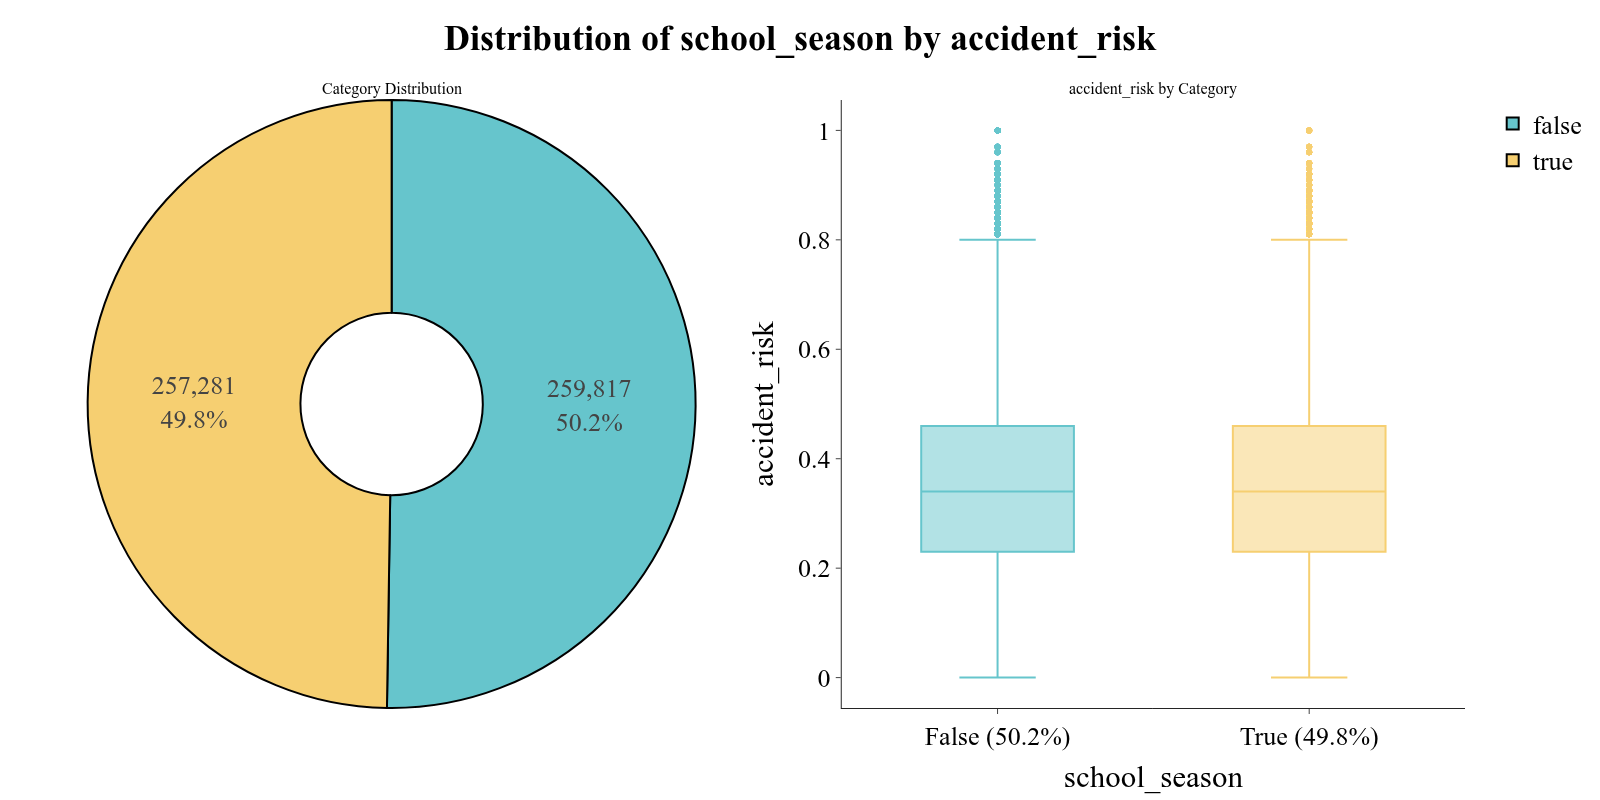

,Category,Count,Percentage (%)
0,False,"259,817",50.25%
1,True,"257,281",49.75%


In [21]:
feature = "school_season"
categorical_plots.pie_boxplot_by_categorical(train_data, feature, target_feature, plot_title=f"Distribution of {feature} by {target_feature}")
data_analyzer.describe_categorical_feature(train_data, feature)

**Notes:**

**Conclusion:**

## `num_reported_accidents`

`num_reported_accidents` (int64) - The number of accidents that have been officially reported on this road segment. This provides historical context for accident frequency.

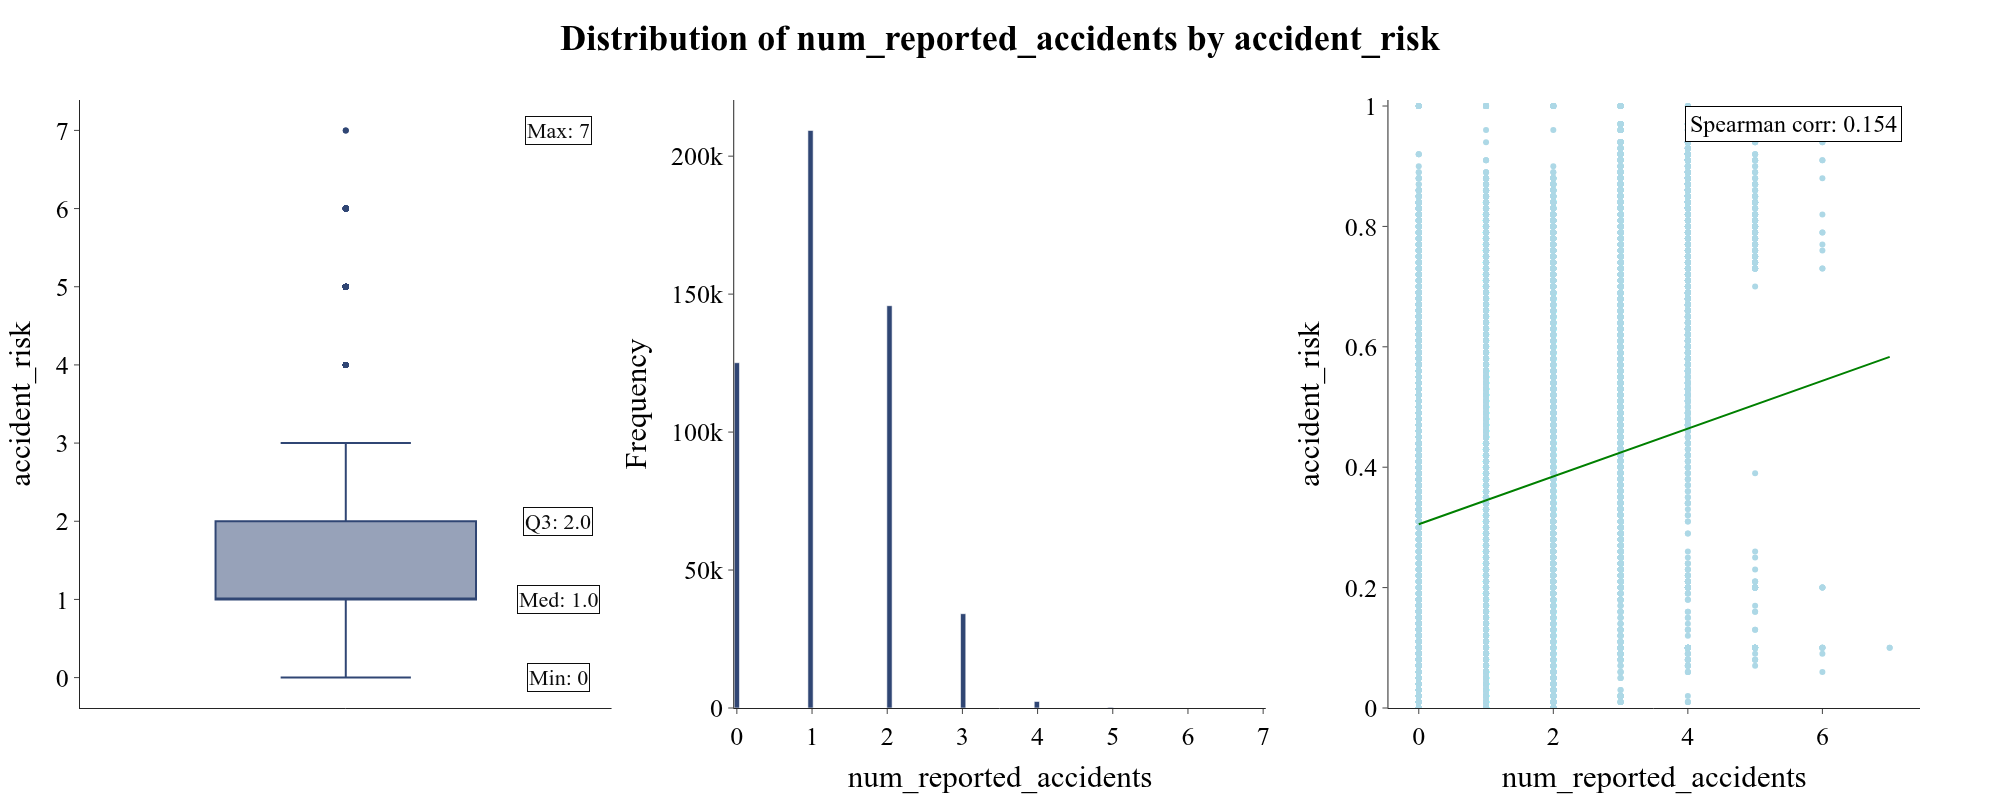

,Count,Mean,Std,Min,5%,Q1,Median,Q3,95%,Max,variance,skewness,kurtosis,Missing,Missing (%)
num_reported_accidents,"517,098",1.19,0.90,0.00,0.00,1.00,1.00,2.00,3.00,7.00,0.80,0.37,-0.32,0,0.00%


In [22]:
feature = "num_reported_accidents"
continuous_plots.histogram_boxplot_linear_regression(train_data, feature, target_feature, plot_title=f"Distribution of {feature} by {target_feature}")
data_analyzer.describe_numerical_feature(train_data, feature)

**Notes:**

**Conclusion:**

# Feature engineering

In [23]:
import pandas as pd
from itertools import combinations
from tqdm import tqdm
import gc


class CrossFeatureGenerator:
    """
    Class for generating cross-encoded features by creating combinations of categorical features.
    """

    def __init__(
        self, features_names: list[str] = [], degree: int = 2, separator: str = "_"
    ):
        """
        Initialize the CrossFeatureGenerator.

        Args:
            features_names (list[str]): List of feature names to create combinations from. If empty, all columns from the DataFrame will be used.
            degree (int): Degree of combinations to generate (default is 2).
            separator (str): Separator to use when combining feature values (default is '_').
        """
        self.features_names = features_names
        self.degree = degree
        self.separator = separator
        self.feature_combinations_ = []
        self.encoding_maps_ = {}
        self.numerical_combos_ = set()  # Track which combinations are numerical
        self._validate_init_params()

    def _validate_init_params(self):
        """
        Validate the parameters for cross feature generation.
        """
        if not isinstance(self.features_names, list) or not all(
            isinstance(name, str) for name in self.features_names
        ):
            raise ValueError("features_names must be a list of strings.")
        if not isinstance(self.degree, int) or self.degree < 2:
            raise ValueError("degree must be an integer >= 2.")
        if not isinstance(self.separator, str):
            raise ValueError("separator must be a string.")
        if self.features_names and len(self.features_names) < self.degree:
            raise ValueError(
                f"Number of features ({len(self.features_names)}) must be >= degree ({self.degree})."
            )

    def _is_numerical_combo(self, df: pd.DataFrame, columns: list) -> bool:
        """
        Check if all columns in the combination are numerical.

        Args:
            df (pd.DataFrame): DataFrame to check
            columns (list): List of column names to check

        Returns:
            bool: True if all columns are numerical, False otherwise
        """
        return all(pd.api.types.is_numeric_dtype(df[col]) for col in columns)

    def fit(self, df: pd.DataFrame) -> "CrossFeatureGenerator":
        """
        Fit the CrossFeatureGenerator by computing encoding maps for feature combinations.

        Args:
            df (pd.DataFrame): DataFrame to fit on.

        Returns:
            CrossFeatureGenerator: Fitted instance.
        """
        # If no features specified, use all columns from df
        if not self.features_names:
            self.features_names = list(df.columns)
            if len(self.features_names) < self.degree:
                raise ValueError(
                    f"Number of features ({len(self.features_names)}) must be >= degree ({self.degree})."
                )

        self.feature_combinations_ = list(
            combinations(sorted(self.features_names), self.degree)
        )
        self.encoding_maps_ = {}
        self.numerical_combos_ = set()

        for combo in tqdm(
            self.feature_combinations_, desc=f"Fitting {self.degree}-way combinations"
        ):
            combo_name = "-".join(combo)

            # Check if all columns in the combo are numerical
            is_numerical = self._is_numerical_combo(df, combo)

            if is_numerical:
                self.numerical_combos_.add(combo_name)
            else:
                combined_values = (
                    df[list(combo)].astype(str).agg(self.separator.join, axis=1)
                )
                unique_values = combined_values.unique()
                encoding_map = {val: idx for idx, val in enumerate(unique_values)}
                self.encoding_maps_[combo_name] = encoding_map
                del combined_values, unique_values
                gc.collect()
        gc.collect()
        return self

    def transform(self, df: pd.DataFrame) -> pd.DataFrame:
        """
        Transform the DataFrame by adding cross-encoded features.

        Args:
            df (pd.DataFrame): DataFrame to transform.

        Returns:
            pd.DataFrame: DataFrame with cross-encoded features added.
        """
        if (
            not hasattr(self, "numerical_combos_")
            or (not self.encoding_maps_ and not self.numerical_combos_)
            or not self.feature_combinations_
        ):
            raise ValueError("CrossFeatureGenerator must be fitted before transform.")

        result_df = df.copy()

        for combo in tqdm(
            self.feature_combinations_,
            desc=f"Transforming {self.degree}-way combinations",
        ):
            combo_name = "-".join(combo)

            if combo_name in self.numerical_combos_:
                result_df[combo_name] = df[list(combo)].prod(axis=1)
            else:
                encoding_map = self.encoding_maps_[combo_name]
                combined_values = (
                    df[list(combo)].astype(str).agg(self.separator.join, axis=1)
                )
                result_df[combo_name] = (
                    combined_values.map(encoding_map).fillna(-1).astype("int32")
                )
                del combined_values
                gc.collect()
        gc.collect()
        return result_df

    def fit_transform(self, df: pd.DataFrame) -> pd.DataFrame:
        """
        Fit and transform the DataFrame with cross-encoded features.

        Args:
            df (pd.DataFrame): DataFrame to fit and transform.

        Returns:
            pd.DataFrame: DataFrame with cross-encoded features added.
        """
        result = self.fit(df).transform(df)
        gc.collect()
        return result

    def get_feature_names(self) -> list[str]:
        """
        Get the names of the generated cross features.

        Returns:
            list[str]: List of generated feature names.
        """
        if not self.feature_combinations_:
            return []
        return ["-".join(combo) for combo in self.feature_combinations_]

In [24]:
def custom_features_generation_before_preprocessing(
    df: pd.DataFrame
) -> pd.DataFrame:
    """
    Add custom features before applying preprocessing steps.

    Args:
        df (pd.DataFrame): DataFrame to which custom features will be added.

    Returns:
        pd.DataFrame: DataFrame with custom features added.
    """
    df_new = df.copy()
    df_new["num_lanes_squared"] = df_new["num_lanes"] ** 2
    df_new["is_single_lane"] = (df_new["num_lanes"] == 1).astype(int)
    df_new["is_multilane"] = (df_new["num_lanes"] > 2).astype(int)
    df_new["lane_density"] = df_new["num_lanes"] / df_new["num_lanes"].max()
    df_new["curvature_squared"] = df_new["curvature"] ** 2
    df_new["curvature_log"] = np.log1p(df_new["curvature"])
    df_new["high_curvature"] = (
        df_new["curvature"] > df_new["curvature"].quantile(0.75)
    ).astype(int)
    df_new["curvature_bin"] = pd.qcut(
        df_new["curvature"], q=5, labels=False, duplicates="drop"
    )
    df_new["speed_limit_squared"] = df_new["speed_limit"] ** 2
    df_new["speed_limit_sqrt"] = np.sqrt(df_new["speed_limit"])
    df_new["high_speed_limit"] = (
        df_new["speed_limit"] > df_new["speed_limit"].quantile(0.75)
    ).astype(int)
    df_new["speed_limit_bin"] = pd.qcut(
        df_new["speed_limit"], q=3, labels=["low", "medium", "high"], duplicates="drop"
    )
    df_new["speed_limit_normalized"] = (
        df_new["speed_limit"] / 100
    )
    df_new["num_accidents_log"] = np.log1p(df_new["num_reported_accidents"])
    df_new["has_previous_accidents"] = (df_new["num_reported_accidents"] > 0).astype(
        int
    )
    df_new["high_accident_history"] = (
        df_new["num_reported_accidents"]
        > df_new["num_reported_accidents"].quantile(0.75)
    ).astype(int)
    upper_limit = df_new["num_reported_accidents"].quantile(0.99)
    df_new["num_accidents_clipped"] = df_new["num_reported_accidents"].clip(
        upper=upper_limit
    )
    road_type_counts = df_new["road_type"].value_counts(normalize=True)
    df_new["road_type_freq"] = df_new["road_type"].map(road_type_counts)
    df_new["is_highway"] = (
        df_new["road_type"]
        .str.contains("highway|motorway|freeway", case=False)
        .astype(int)
    )
    df_new["is_residential"] = (
        df_new["road_type"].str.contains("residential|local", case=False).astype(int)
    )
    df_new["is_poor_lighting"] = (
        ~df_new["lighting"].isin(["daylight", "good lighting"])
    ).astype(int)
    df_new["is_no_lighting"] = (df_new["lighting"] == "no lighting").astype(int)
    df_new["is_adverse_weather"] = (
        df_new["weather"].isin(["rain", "snow", "fog", "sleet", "storm"]).astype(int)
    )
    df_new["is_clear_weather"] = (
        df_new["weather"].isin(["clear", "sunny", "fair"]).astype(int)
    )
    df_new["is_precipitation"] = (
        df_new["weather"].isin(["rain", "snow", "sleet"]).astype(int)
    )
    df_new["is_night"] = (
        df_new["time_of_day"].isin(["night", "late night", "early morning"]).astype(int)
    )
    df_new["is_rush_hour"] = (
        df_new["time_of_day"]
        .isin(["morning rush", "evening rush", "peak hours"])
        .astype(int)
    )
    df_new["is_weekend"] = (
        df_new["time_of_day"].str.contains("weekend", case=False).astype(int)
    )
    df_new["speed_per_lane"] = df_new["speed_limit"] / (df_new["num_lanes"] + 0.001)
    df_new["speed_curvature_ratio"] = df_new["speed_limit"] / (
        df_new["curvature"] + 0.001
    )
    df_new["curved_road_high_speed"] = (
        df_new["high_curvature"] & df_new["high_speed_limit"]
    ).astype(int)
    df_new["lane_speed_product"] = df_new["num_lanes"] * df_new["speed_limit"]
    df_new["safety_index"] = (
        df_new["road_signs_present"] & df_new["public_road"]
    ).astype(int)
    df_new["unsafe_condition"] = (
        (~df_new["road_signs_present"]) & df_new["high_curvature"]
    ).astype(int)
    df_new["visibility_risk"] = (
        df_new["is_poor_lighting"] & df_new["is_adverse_weather"]
    ).astype(int)
    df_new["school_holiday_interaction"] = (
        df_new["school_season"] & df_new["holiday"]
    ).astype(int)
    df_new["rush_hour_multilane"] = (
        df_new["is_rush_hour"] & df_new["is_multilane"]
    ).astype(int)
    df_new["night_driving_poor_lighting"] = (
        df_new["is_night"] & df_new["is_poor_lighting"]
    ).astype(int)
    df_new["school_day_residential"] = (
        df_new["school_season"] & df_new["is_residential"]
    ).astype(int)
    df_new["high_speed_no_signs"] = (
        df_new["high_speed_limit"] & (~df_new["road_signs_present"])
    ).astype(int)
    risk_factors = [
        "high_curvature",
        "high_speed_limit",
        "is_poor_lighting",
        "is_adverse_weather",
        "is_night",
        "is_rush_hour",
    ]
    df_new["risk_factor_count"] = df_new[risk_factors].sum(axis=1)
    weights = {
        "high_curvature": 2,
        "high_speed_limit": 1.5,
        "is_poor_lighting": 1.2,
        "is_adverse_weather": 1.3,
        "is_night": 1.1,
        "is_rush_hour": 0.8,
    }
    df_new["weighted_risk_score"] = sum(
        df_new[col] * weight for col, weight in weights.items()
    )
    safety_factors = ["road_signs_present", "public_road"]
    df_new["safety_neglect_score"] = 2 - df_new[safety_factors].sum(axis=1)
    df_new["infrastructure_score"] = (
        df_new["road_signs_present"].astype(int)
        + df_new["public_road"].astype(int)
        - df_new["high_curvature"]
    )
    df_new["accident_density"] = df_new["num_reported_accidents"] / (
        df_new["num_lanes"] + 0.001
    )
    df_new["speed_accident_interaction"] = df_new["speed_limit"] * np.log1p(
        df_new["num_reported_accidents"]
    )
    time_risk_map = {
        "night": 1.5,
        "late night": 1.8,
        "early morning": 1.2,
        "rush hour": 1.4,
        "evening": 1.1,
        "afternoon": 0.9,
        "morning": 1.0,
        "midday": 0.8,
    }
    default_time_risk = 1.0
    df_new["time_risk_factor"] = (
        df_new["time_of_day"]
        .map(
            {
                k: v
                for k, v in time_risk_map.items()
                if k in df_new["time_of_day"].unique()
            }
        )
        .fillna(default_time_risk)
    )
    df_new["combined_environmental_risk"] = (
        df_new["is_adverse_weather"] + df_new["is_poor_lighting"] + df_new["is_night"]
    ) / 3

    df_new["road_complexity_score"] = (
        (
            df_new["curvature_normalized"]
            if "curvature_normalized" in df_new.columns
            else df_new["curvature"] / df_new["curvature"].max()
        )
        * (df_new["num_lanes"] / 4)
        * (df_new["speed_limit"] / 100)
    )
    return df_new

steps = [
    # CrossFeatureGenerator(features_names=[], degree=2),
    # TargetEncodingFeatureGenerator(
    #     features_names=[],
    #     aggregation="mean",
    #     smooth=10,
    #     cv=KFold(n_splits=5, shuffle=True, random_state=17),
    # ),
    # CountEncodingFeatureGenerator(features_names=[], fill_value=0),
]

feature_generation_pipeline = FeatureGenerationPipeline(
    features_names=list(set(train_data.columns) - {target_feature}),
    preprocessing_steps=steps,
    # custom_features_generation_before_preprocessing=custom_features_generation_before_preprocessing,
)

X_train = train_data.drop(columns=[target_feature])
y_train = pd.qcut(train_data[target_feature], q=10, labels=False)
X_test = test_data.drop(columns=[target_feature], errors='ignore')

X_train = feature_generation_pipeline.fit_transform(X=X_train, y=y_train)
X_test = feature_generation_pipeline.transform(X=X_test)

train_data = pd.concat([X_train, train_data[target_feature]], axis=1)
test_data = X_test.copy()
train_data.head()

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
0,urban,2,0.06,35,daylight,rainy,False,True,afternoon,False,True,1,0.13
1,urban,4,0.99,35,daylight,clear,True,False,evening,True,True,0,0.35
2,rural,4,0.63,70,dim,clear,False,True,morning,True,False,2,0.30
3,highway,4,0.07,35,dim,rainy,True,True,morning,False,False,1,0.21
4,rural,1,0.58,60,daylight,foggy,False,False,evening,True,False,1,0.56


### Clean data if there are some redundant features

In [25]:
train_data = data_cleaner.initial_features_removal(train_data)
train_data = data_cleaner.drop_highly_skewed_categorical_features(train_data, features_to_investigate=train_data.drop(columns=[target_feature]).columns.tolist(), threshold=0.99)


Number of features after removal: 13. Removed 0 features.


## Dtypes conversion (memory optimization)

In [26]:
categorical_features = data_analyzer.get_categorical_features(train_data, unique_threshold=100)
independent_features = list(set(train_data.columns) - {target_feature})
print("Train data memory optimization:")
train_data = data_transformer.optimize_memory(train_data, categorical_features=categorical_features, verbose=True)
print("\nTest data memory optimization:")
test_data = data_transformer.optimize_memory(test_data, categorical_features=categorical_features, verbose=True)
if target_feature in categorical_features:
    categorical_features.remove(target_feature)
    train_data[target_feature] = train_data[target_feature].cat.codes

Train data memory optimization:
Numerical dtypes reduced: 130.02 MB → 115.72 MB (11.0% reduction)
Categorical dtypes converted: 115.72 MB → 9.37 MB (91.9% reduction)
Total memory usage reduced: 130.02 MB → 9.37 MB (92.8% reduction)

Test data memory optimization:
Numerical dtypes reduced: 43.40 MB → 39.28 MB (9.5% reduction)
Categorical dtypes converted: 39.28 MB → 3.79 MB (90.4% reduction)
Total memory usage reduced: 43.40 MB → 3.79 MB (91.3% reduction)


# Summary of data analysis

In [27]:
data_analyzer.base_information(train_data)

,Feature,dtypes,Number of missing values,Percentage of missing values,Unique values,Count
0,road_type,category,0,0.00%,3,"517,098"
1,num_lanes,int8,0,0.00%,4,"517,098"
2,curvature,float32,0,0.00%,261,"517,098"
3,speed_limit,int8,0,0.00%,5,"517,098"
4,lighting,category,0,0.00%,3,"517,098"
5,weather,category,0,0.00%,3,"517,098"
6,road_signs_present,category,0,0.00%,2,"517,098"
7,public_road,category,0,0.00%,2,"517,098"
8,time_of_day,category,0,0.00%,3,"517,098"
9,holiday,category,0,0.00%,2,"517,098"


# Baseline modeling

### LightGBM

In [28]:
model = LGBMRegressor(boosting_type='gbdt', random_state=SEED, n_jobs=-1, objective='regression', metric='rmse', verbose=-1, early_stopping_rounds=100)
train_scores, valid_scores, _ = cross_validation_trainer.fit(estimator=model, X=train_data[independent_features], y=train_data[target_feature])
print(f"Train {METRIC_NAME}: {np.mean(train_scores):.4f} +- {np.std(train_scores):.4f}")
print(f"Validation {METRIC_NAME}: {np.mean(valid_scores):.4f} +- {np.std(valid_scores):.4f}")

Train RMSE: 0.0560 +- 0.0001
Validation RMSE: 0.0562 +- 0.0003


### LightGBM (goss)

In [29]:
model = LGBMRegressor(boosting_type='goss', random_state=SEED, n_jobs=-1, objective='regression', metric='rmse', verbose=-1, early_stopping_rounds=100)
train_scores, valid_scores, _ = cross_validation_trainer.fit(estimator=model, X=train_data[independent_features], y=train_data[target_feature])
print(f"Train {METRIC_NAME}: {np.mean(train_scores):.4f} +- {np.std(train_scores):.4f}")
print(f"Validation {METRIC_NAME}: {np.mean(valid_scores):.4f} +- {np.std(valid_scores):.4f}")

Train RMSE: 0.0561 +- 0.0001
Validation RMSE: 0.0562 +- 0.0003


### XGBoost

In [30]:
model = XGBRegressor(booster="gbtree", random_state=SEED, n_jobs=-1, objective='reg:squarederror', eval_metric='rmse', enable_categorical=True, tree_method='hist', verbosity=0, early_stopping_rounds=100)
train_scores, valid_scores, _ = cross_validation_trainer.fit(estimator=model, X=train_data[independent_features], y=train_data[target_feature])
print(f"Train {METRIC_NAME}: {np.mean(train_scores):.4f} +- {np.std(train_scores):.4f}")
print(f"Validation {METRIC_NAME}: {np.mean(valid_scores):.4f} +- {np.std(valid_scores):.4f}")

Train RMSE: 0.0556 +- 0.0001
Validation RMSE: 0.0561 +- 0.0003


### Histogram-based Gradient Boosting

In [31]:
model = HistGradientBoostingRegressor(random_state=SEED, categorical_features=categorical_features, early_stopping=True, scoring='neg_root_mean_squared_error', verbose=0)
train_scores, valid_scores, _ = cross_validation_trainer.fit(estimator=model, X=train_data[independent_features], y=train_data[target_feature])
print(f"Train {METRIC_NAME}: {np.mean(train_scores):.4f} +- {np.std(train_scores):.4f}")
print(f"Validation {METRIC_NAME}: {np.mean(valid_scores):.4f} +- {np.std(valid_scores):.4f}")

Train RMSE: 0.0560 +- 0.0001
Validation RMSE: 0.0562 +- 0.0003


### CatBoost

In [32]:
model = CatBoostRegressor(random_state=SEED, verbose=0, cat_features=categorical_features, task_type='GPU', loss_function='RMSE', eval_metric='RMSE', early_stopping_rounds=100, allow_writing_files=False)
train_scores, valid_scores, _ = cross_validation_trainer.fit(estimator=model, X=train_data[independent_features], y=train_data[target_feature])
print(f"Train {METRIC_NAME}: {np.mean(train_scores):.4f} +- {np.std(train_scores):.4f}")
print(f"Validation {METRIC_NAME}: {np.mean(valid_scores):.4f} +- {np.std(valid_scores):.4f}")

Train RMSE: 0.0557 +- 0.0001
Validation RMSE: 0.0562 +- 0.0003


## Ensemble model

In [33]:
estimators = [
    LGBMRegressor(boosting_type='gbdt', random_state=SEED, n_jobs=-1, objective='regression', metric='rmse', verbose=-1, early_stopping_rounds=100),
    LGBMRegressor(boosting_type='goss', random_state=SEED, n_jobs=-1, objective='regression', metric='rmse', verbose=-1, early_stopping_rounds=100),
    XGBRegressor(booster="gbtree", random_state=SEED, n_jobs=-1, objective='reg:squarederror', eval_metric='rmse', enable_categorical=True, tree_method='hist', verbosity=0, early_stopping_rounds=100),
    HistGradientBoostingRegressor(random_state=SEED, categorical_features=categorical_features, early_stopping=True, scoring='neg_root_mean_squared_error', verbose=0),
    CatBoostRegressor(random_state=SEED, verbose=0, cat_features=categorical_features, task_type='GPU', loss_function='RMSE', eval_metric='RMSE', early_stopping_rounds=100, allow_writing_files=False)
]
ensemble_model = EnsembleModel(estimators=estimators, problem_type=PROBLEM_TYPE)
train_scores, valid_scores, _ = cross_validation_trainer.fit(estimator=ensemble_model, X=train_data[independent_features], y=train_data[target_feature])
print(f"Train {METRIC_NAME}: {np.mean(train_scores):.4f} +- {np.std(train_scores):.4f}")
print(f"Validation {METRIC_NAME}: {np.mean(valid_scores):.4f} +- {np.std(valid_scores):.4f}")

Train RMSE: 0.0558 +- 0.0001
Validation RMSE: 0.0561 +- 0.0003


# Feature selection

In [ ]:
shap_rfe = ShapRecursiveFeatureElimination(
    estimator=ensemble_model,
    cross_validator=cross_validation_trainer,
    problem_type=PROBLEM_TYPE,
    steps=50,
    alpha=0.99,
    verbose=True
)
shap_rfe_summary = shap_rfe.run(train_data[independent_features], train_data[target_feature])
other_plots.plot_metric_change_vs_features_removed(shap_rfe_summary["history"], optimal_n_features=len(shap_rfe_summary["selected_features"]), plot_title=f"SHAP RFE - {METRIC_NAME} change vs features removed")

In [ ]:
selected_features, metric_value = shap_rfe.select_features_weighted_score(shap_rfe_summary["history"], alpha=0.8)
other_plots.plot_metric_change_vs_features_removed(shap_rfe_summary["history"], optimal_n_features=len(selected_features))
print(f"Number of features selected: {len(selected_features)}")
print(f"Selected features: {selected_features}")
print(f"{METRIC_NAME} after feature selection: {metric_value:.6f}")

In [ ]:
selected_features = ['parameters_dict_no_accident', 'details_country_origin_extracted', 'details_engine_capacity_float', 'model_code', 'parameters_dict_ventilated_rear_seat', 'vader_compound', 'textblob_polarity', 'seller_working_hours_day_3_open_at', 'generation_year_start', 'seller_services_tire_change', 'details_engine_power_float', 'seller_features_badge_registration_year', 'keyword_kół', 'parameters_dict_upholstery_type', 'seller_location_longitude', 'equipment_systemy_wspomagania_kierowcy_kamera_w_lusterku_bocznym', 'equipment_komfort_i_dodatki_tapicerka_materiałowa', 'details_gearbox', 'parameters_dict_is_imported_car', 'package', 'flesch_kincaid_grade', 'details_registered', 'equipment_komfort_i_dodatki_sportowe_fotele_przód', 'parameters_dict_sport_suspension', 'exclamation_count', 'main_features_length', 'details_color', 'seller_features_badge_fast-reply', 'reading_time', 'fuel', 'parameters_dict_tinted_rear_windows', 'parameters_dict_vat', 'equipment_komfort_i_dodatki_word_count', 'parameters_dict_tuning', 'details_door_count', 'details_body_type', 'textblob_subjectivity', 'lexicon_count', 'details_year', 'trim', 'parameters_dict_alloy_wheels_type', 'parameters_dict_head_up_display', 'details_transmission', 'question_count', 'syllable_count', 'difficult_words', 'generation_year_end', 'seller_working_hours_day_5_close_at', 'seller_working_hours_day_0_close_at', 'details_monthly_payment_float', 'seller_working_hours_day_6_close_at', 'number_of_photos', 'verified_car', 'details_mileage_float', 'equipment_komfort_i_dodatki_wycieraczki', 'details_new_used', 'details_fuel_type', 'listing_age_days', 'details_model', 'details_nr_seats', 'seller_services_tinsmith', 'seller_working_hours_day_1_open_at', 'seller_number_of_active_ads', 'equipment_audio_i_multimedia_length', 'parameters_dict_registered', 'generation_code', 'keyword_wkładu', 'seller_services_length']
selected_features = shap_rfe_summary["selected_features"]

In [ ]:
independent_features = selected_features.copy()
categorical_features = [feature for feature in independent_features if train_data[feature].dtype.name == 'category']
train_data = train_data[independent_features + [target_feature]].copy()
if target_feature in test_data.columns:
    test_data = test_data[independent_features + [target_feature]].copy()
else:
    test_data = test_data[independent_features].copy()

In [ ]:
train_scores, valid_scores, _ = cross_validation_trainer.fit(estimator=ensemble_model, X=train_data[independent_features], y=train_data[target_feature])
print(f"Train {METRIC_NAME}: {np.mean(train_scores):.4f} +- {np.std(train_scores):.4f}")
print(f"Validation {METRIC_NAME}: {np.mean(valid_scores):.4f} +- {np.std(valid_scores):.4f}")

# Hyperparameter tuning

In [34]:
tuner = RandomSearchCV(cross_validator=cross_validation_trainer, n_trials=N_TRIALS, seed=SEED)

## LightGBM

In [35]:
model = LGBMRegressor()
constant_params_grid = {
    "boosting_type": ("constant", ["gbdt"]),
    "seed": ("constant", [SEED]),
    "verbose": ("constant", [-1]),
    "n_jobs": ("constant", [-1]),
    "early_stopping_rounds": ("constant", [100]),
}
constant_params_grid["objective"] = ("constant", ["regression"])

tunable_params_grid = {
    "n_estimators": ("int", [200, 2000], {"step": 50}),
    "learning_rate": ("float", [1e-4, 0.3], {"log": True}),
    "num_leaves": ("int", [15, 512], {"step": 1}),
    "max_depth": ("int", [-1, 30], {"step": 1}),
    "min_child_samples": ("int", [5, 300], {"step": 5}),
    "subsample": ("float", [0.4, 1.0], {"log": True}),
    "colsample_bytree": ("float", [0.4, 1.0], {"log": True}),
    "reg_alpha": ("float", [1e-4, 10.0], {"log": True}),
    "reg_lambda": ("float", [1e-4, 10.0], {"log": True}),
    "min_split_gain": ("float", [1e-4, 1.0], {"log": True}),
    "bagging_freq": ("int", [0, 10], {"step": 1}),
    "max_bin": ("int", [63, 511], {"step": 32}),
}
tunable_params_grid["metric"] = ("categorical", ["rmse", "l2", "l1"])

params_grid = {**constant_params_grid, **tunable_params_grid}

study = tuner.tune(model, train_data[independent_features], train_data[target_feature], params_grid)
lgbm_best_params = study.best_trial.params
constant_params = {k: v[1][0] for k, v in constant_params_grid.items()}
lgbm_best_params = {**constant_params, **lgbm_best_params}
print(lgbm_best_params)

/home/kvbiii/Programming/Python/Kaggle_Competitions/.venv/lib/python3.12/site-packages/optuna/_experimental.py:32: ExperimentalWarning:

Argument ``multivariate`` is an experimental feature. The interface can change in the future.

[I 2025-10-02 18:11:21,244] A new study created in memory with name: Optuna tuning
[I 2025-10-02 18:11:22,814] Trial 0 finished with value: 0.08163343713093527 and parameters: {'n_estimators': 700, 'learning_rate': 0.0069970420741033885, 'num_leaves': 110, 'max_depth': 1, 'min_child_samples': 240, 'subsample': 0.7298630181242587, 'colsample_bytree': 0.7173895765627012, 'reg_alpha': 0.07551173844071643, 'reg_lambda': 0.00015678863564170368, 'min_split_gain': 0.002699320282307521, 'bagging_freq': 10, 'max_bin': 63, 'metric': 'l2'}. Best is trial 0 with value: 0.08163343713093527.
[I 2025-10-02 18:11:40,374] Trial 1 finished with value: 0.05676725979295577 and parameters: {'n_estimators': 1400, 'learning_rate': 0.008289081528033058, 'num_leaves': 312, 'max_dept

{'boosting_type': 'gbdt', 'seed': 17, 'verbose': -1, 'n_jobs': -1, 'early_stopping_rounds': 100, 'objective': 'regression', 'n_estimators': 1950, 'learning_rate': 0.006858096698074489, 'num_leaves': 146, 'max_depth': 17, 'min_child_samples': 15, 'subsample': 0.965697473102402, 'colsample_bytree': 0.7655902062977548, 'reg_alpha': 0.0003398258940105176, 'reg_lambda': 0.07016760885885114, 'min_split_gain': 0.007615510681065395, 'bagging_freq': 1, 'max_bin': 191, 'metric': 'l1'}


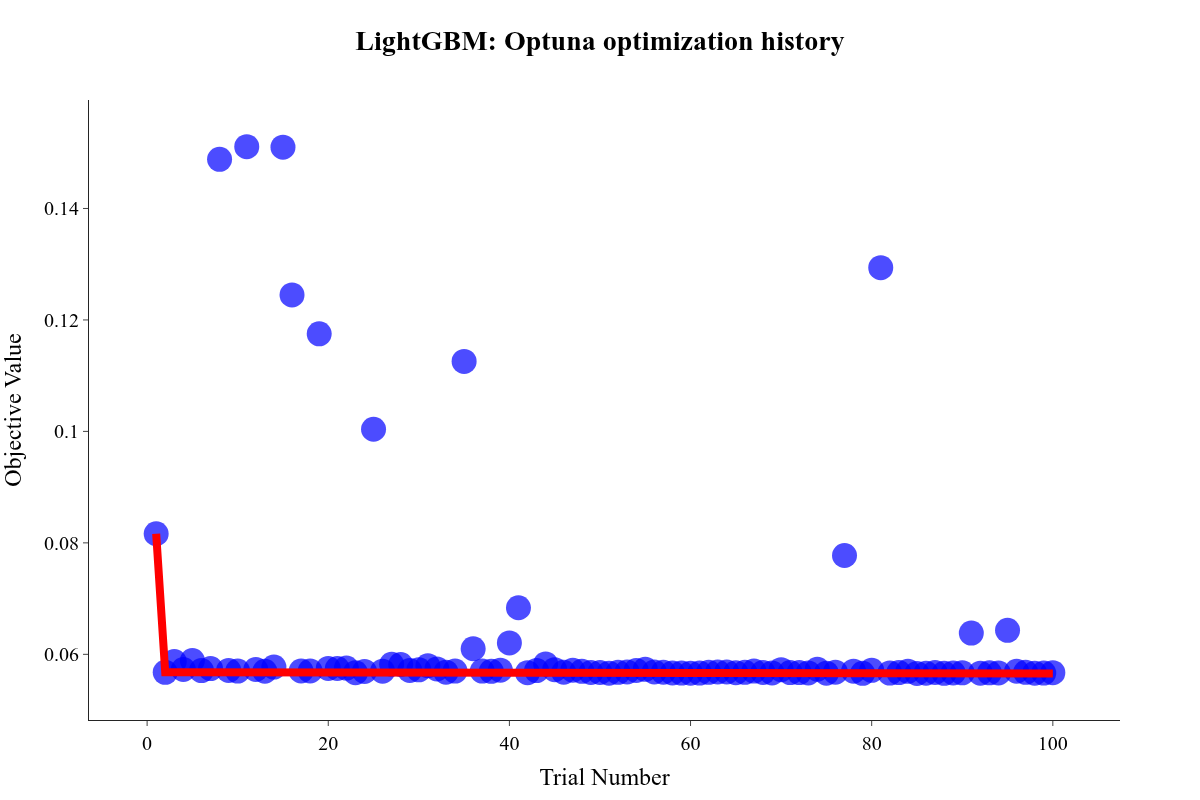

In [36]:
optuna_plots.plot_optuna_optimization_history(study, plot_title="LightGBM: Optuna optimization history", direction=METRICS[METRIC_NAME][2])

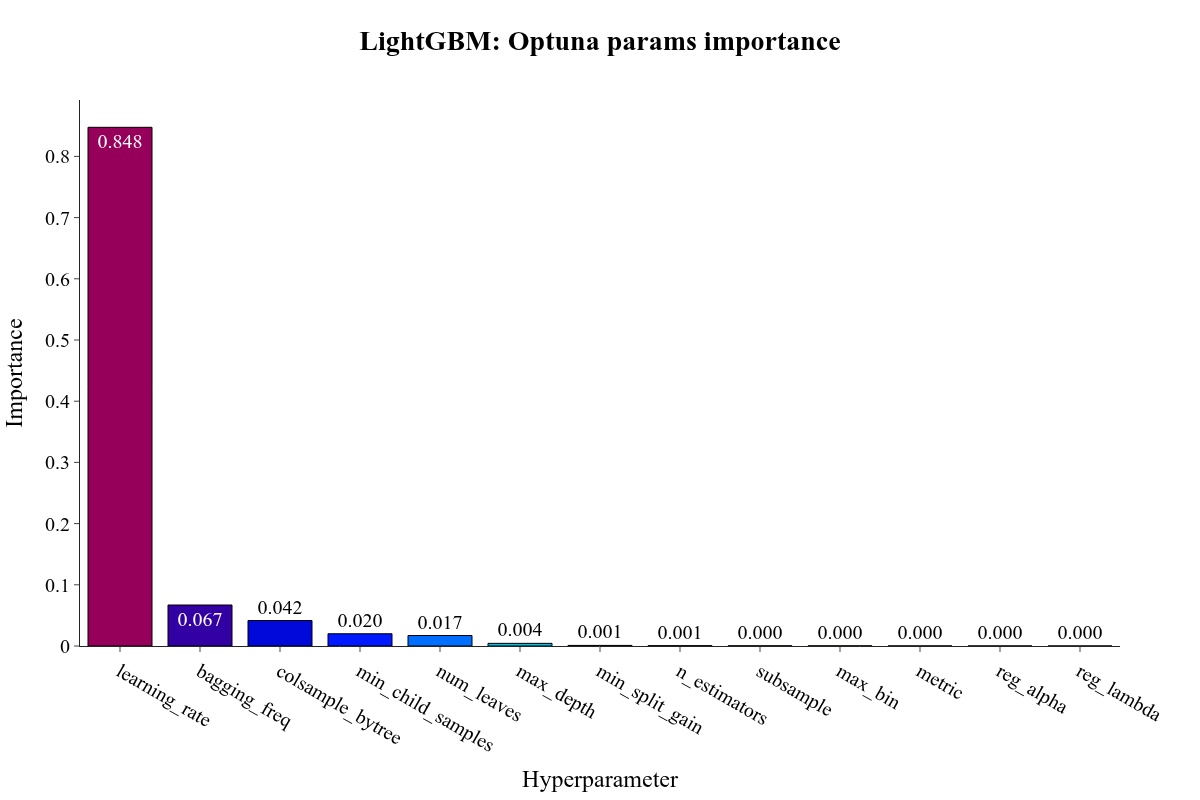

In [37]:
optuna_plots.plot_optuna_param_importance(study, plot_title="LightGBM: Optuna params importance")

In [38]:
model = LGBMRegressor(**lgbm_best_params)
train_scores, valid_scores, _ = cross_validation_trainer.fit(estimator=model, X=train_data[independent_features], y=train_data[target_feature])
print(f"Train {METRIC_NAME}: {np.mean(train_scores):.4f} +- {np.std(train_scores):.4f}")
print(f"Validation {METRIC_NAME}: {np.mean(valid_scores):.4f} +- {np.std(valid_scores):.4f}")

Train RMSE: 0.0558 +- 0.0001
Validation RMSE: 0.0560 +- 0.0003


## LightGBM (goss)

In [39]:
model = LGBMRegressor()
constant_params_grid = {
    "boosting_type": ("constant", ["goss"]),
    "seed": ("constant", [SEED]),
    "verbose": ("constant", [-1]),
    "n_jobs": ("constant", [-1]),
    "early_stopping_rounds": ("constant", [100]),
}
constant_params_grid["objective"] = ("constant", ["regression"])

tunable_params_grid = {
    "n_estimators": ("int", [200, 2000], {"step": 50}),
    "learning_rate": ("float", [1e-4, 0.3], {"log": True}),
    "num_leaves": ("int", [15, 512], {"step": 1}),
    "max_depth": ("int", [-1, 30], {"step": 1}),
    "min_child_samples": ("int", [5, 300], {"step": 5}),
    "subsample": ("float", [0.4, 1.0], {"log": True}),
    "colsample_bytree": ("float", [0.4, 1.0], {"log": True}),
    "reg_alpha": ("float", [1e-4, 10.0], {"log": True}),
    "reg_lambda": ("float", [1e-4, 10.0], {"log": True}),
    "min_split_gain": ("float", [1e-4, 1.0], {"log": True}),
    "max_bin": ("int", [63, 511], {"step": 32}),
}
tunable_params_grid["metric"] = ("categorical", ["rmse", "l2", "l1"])

params_grid = {**constant_params_grid, **tunable_params_grid}

study = tuner.tune(model, train_data[independent_features], train_data[target_feature], params_grid)
lgbm_goss_best_params = study.best_trial.params
constant_params = {k: v[1][0] for k, v in constant_params_grid.items()}
lgbm_goss_best_params = {**constant_params, **lgbm_goss_best_params}
print(lgbm_goss_best_params)

/home/kvbiii/Programming/Python/Kaggle_Competitions/.venv/lib/python3.12/site-packages/optuna/_experimental.py:32: ExperimentalWarning:

Argument ``multivariate`` is an experimental feature. The interface can change in the future.

[I 2025-10-02 18:26:05,836] A new study created in memory with name: Optuna tuning
[I 2025-10-02 18:26:07,804] Trial 0 finished with value: 0.08127252830034973 and parameters: {'n_estimators': 700, 'learning_rate': 0.0069970420741033885, 'num_leaves': 110, 'max_depth': 1, 'min_child_samples': 240, 'subsample': 0.7298630181242587, 'colsample_bytree': 0.7173895765627012, 'reg_alpha': 0.07551173844071643, 'reg_lambda': 0.00015678863564170368, 'min_split_gain': 0.002699320282307521, 'max_bin': 511, 'metric': 'l1'}. Best is trial 0 with value: 0.08127252830034973.
[I 2025-10-02 18:26:09,687] Trial 1 finished with value: 0.059690101881850734 and parameters: {'n_estimators': 250, 'learning_rate': 0.018558318967817976, 'num_leaves': 289, 'max_depth': 18, 'min_child_

{'boosting_type': 'goss', 'seed': 17, 'verbose': -1, 'n_jobs': -1, 'early_stopping_rounds': 100, 'objective': 'regression', 'n_estimators': 1400, 'learning_rate': 0.01130557141827777, 'num_leaves': 112, 'max_depth': 15, 'min_child_samples': 10, 'subsample': 0.4735870642469657, 'colsample_bytree': 0.7610123036301918, 'reg_alpha': 0.010835821706420794, 'reg_lambda': 1.0853942846351743, 'min_split_gain': 0.00552383650790889, 'max_bin': 479, 'metric': 'l2'}


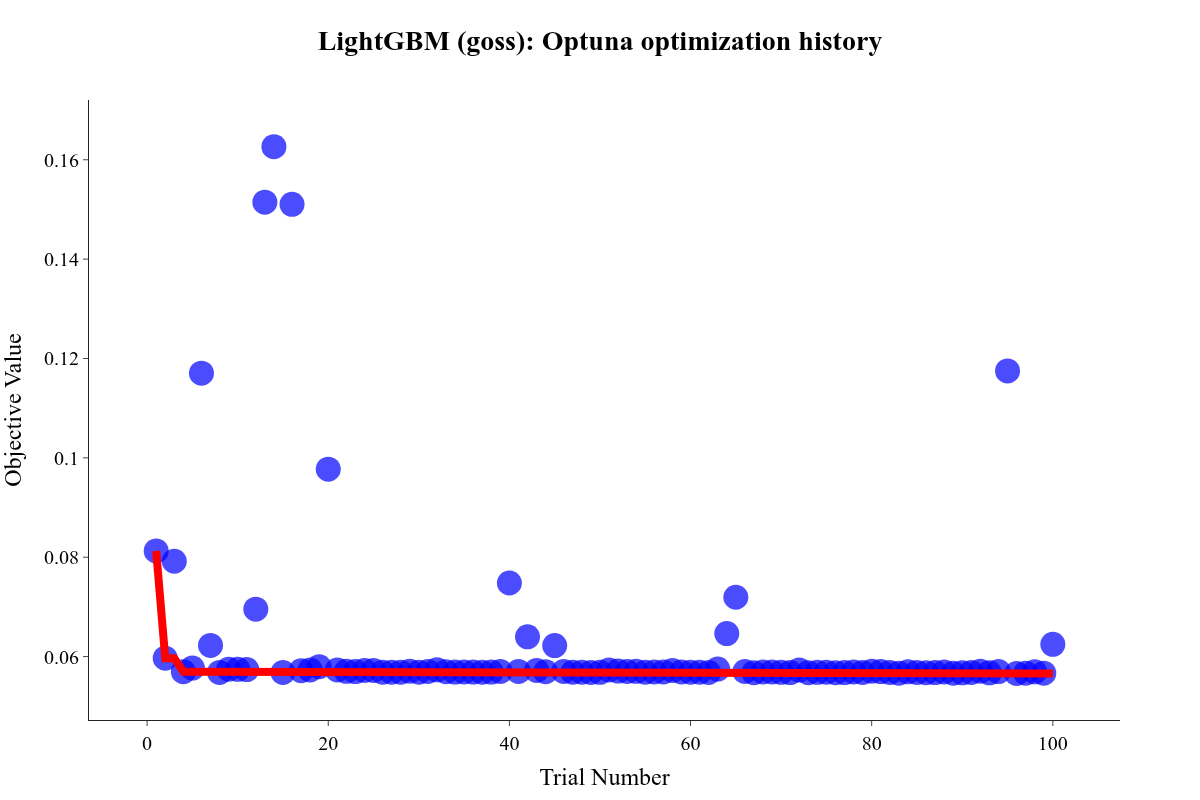

In [40]:
optuna_plots.plot_optuna_optimization_history(study, plot_title="LightGBM (goss): Optuna optimization history", direction=METRICS[METRIC_NAME][2])

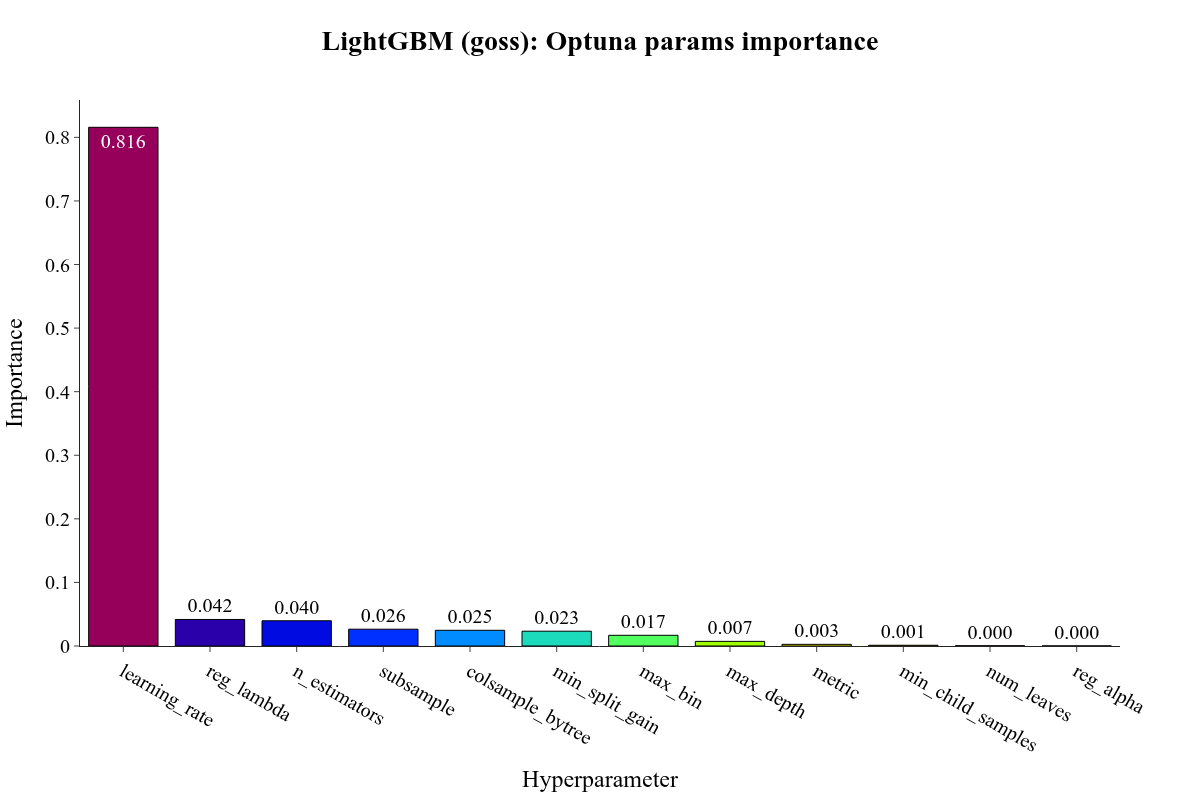

In [41]:
optuna_plots.plot_optuna_param_importance(study, plot_title="LightGBM (goss): Optuna params importance")

In [42]:
model = LGBMRegressor(**lgbm_goss_best_params)
train_scores, valid_scores, _ = cross_validation_trainer.fit(estimator=model, X=train_data[independent_features], y=train_data[target_feature])
print(f"Train {METRIC_NAME}: {np.mean(train_scores):.4f} +- {np.std(train_scores):.4f}")
print(f"Validation {METRIC_NAME}: {np.mean(valid_scores):.4f} +- {np.std(valid_scores):.4f}")

Train RMSE: 0.0556 +- 0.0001
Validation RMSE: 0.0560 +- 0.0003


## XGBoost

In [43]:
model = XGBRegressor()
constant_params_grid = {
    "seed": ("constant", [SEED]),
    "verbosity": ("constant", [0]),
    "n_jobs": ("constant", [-1]),
    "tree_method": ("constant", ["hist"]),
    "enable_categorical": ("constant", [True]),
    "early_stopping_rounds": ("constant", [100]),
}
constant_params_grid["objective"] = ("constant", ["reg:squarederror"])

tunable_params_grid = {
    "n_estimators": ("int", [200, 2000], {"step": 50}),
    "learning_rate": ("float", [1e-4, 0.3], {"log": True}),
    "max_depth": ("int", [0, 30], {"step": 1}),
    "min_child_weight": ("int", [1, 296], {"step": 5}),
    "subsample": ("float", [0.4, 1.0], {"log": False}),
    "colsample_bytree": ("float", [0.4, 1.0], {"log": False}),
    "gamma": ("float", [1e-4, 10.0], {"log": True}),
    "reg_alpha": ("float", [1e-4, 10.0], {"log": True}),
    "reg_lambda": ("float", [1e-4, 10.0], {"log": True}),
    "max_bin": ("int", [63, 511], {"step": 32}),
}
tunable_params_grid["eval_metric"] = ("categorical", ["rmse", "mae", "logloss"])

params_grid = {**constant_params_grid, **tunable_params_grid}


study = tuner.tune(model, train_data[independent_features], train_data[target_feature], params_grid)
xgb_best_params = study.best_trial.params
constant_params = {k: v[1][0] for k, v in constant_params_grid.items()}
xgb_best_params = {**constant_params, **xgb_best_params}
print(xgb_best_params)

/home/kvbiii/Programming/Python/Kaggle_Competitions/.venv/lib/python3.12/site-packages/optuna/_experimental.py:32: ExperimentalWarning:

Argument ``multivariate`` is an experimental feature. The interface can change in the future.

[I 2025-10-02 18:43:22,351] A new study created in memory with name: Optuna tuning
[I 2025-10-02 18:43:26,146] Trial 0 finished with value: 0.057259246706962585 and parameters: {'n_estimators': 700, 'learning_rate': 0.0069970420741033885, 'max_depth': 5, 'min_child_weight': 21, 'subsample': 0.872191275999948, 'colsample_bytree': 0.7938001130655132, 'gamma': 0.15402970378226535, 'reg_alpha': 0.07551173844071643, 'reg_lambda': 0.00015678863564170368, 'max_bin': 223, 'eval_metric': 'rmse'}. Best is trial 0 with value: 0.057259246706962585.
[I 2025-10-02 18:43:55,264] Trial 1 finished with value: 0.14208874702453614 and parameters: {'n_estimators': 1800, 'learning_rate': 0.00015066299028163713, 'max_depth': 20, 'min_child_weight': 166, 'subsample': 0.75850795194

{'seed': 17, 'verbosity': 0, 'n_jobs': -1, 'tree_method': 'hist', 'enable_categorical': True, 'early_stopping_rounds': 100, 'objective': 'reg:squarederror', 'n_estimators': 900, 'learning_rate': 0.13022733416877924, 'max_depth': 21, 'min_child_weight': 36, 'subsample': 0.9813477111677613, 'colsample_bytree': 0.9583209055111086, 'gamma': 0.01932644816406137, 'reg_alpha': 0.0005304442176255451, 'reg_lambda': 2.9015008792510466, 'max_bin': 351, 'eval_metric': 'rmse'}


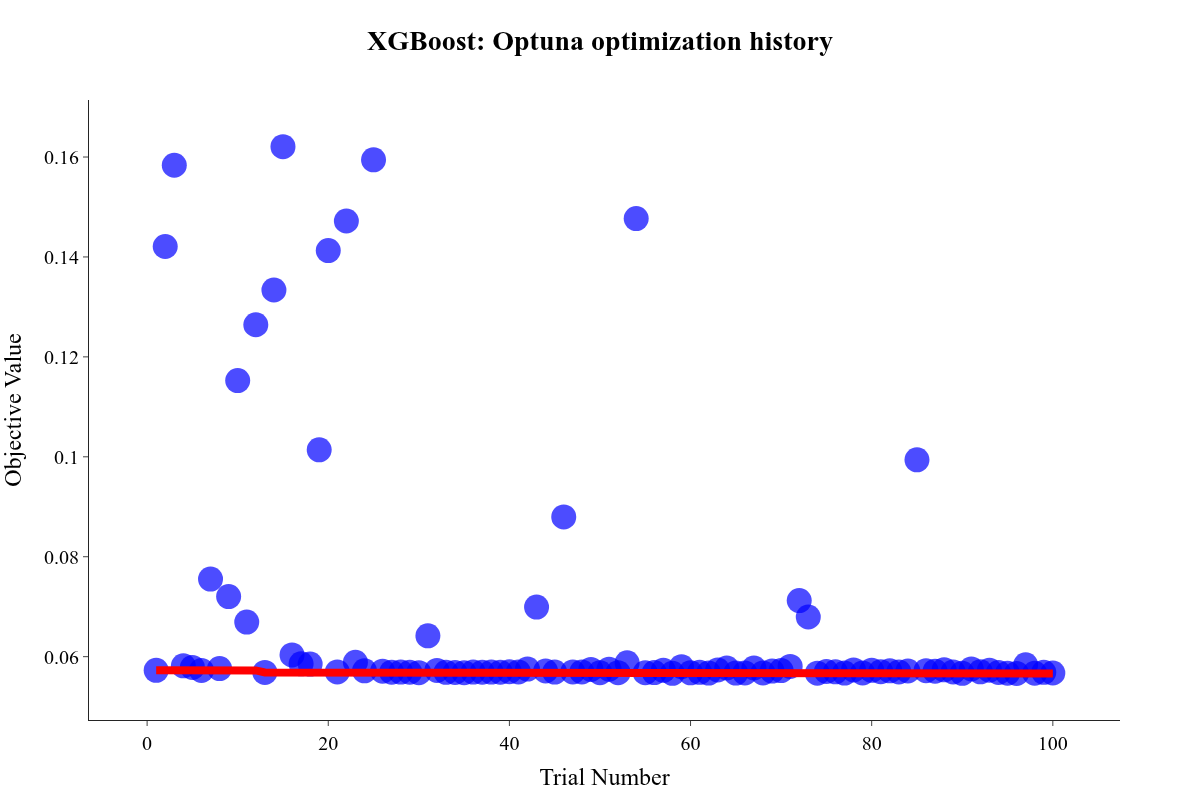

In [44]:
optuna_plots.plot_optuna_optimization_history(study, plot_title="XGBoost: Optuna optimization history", direction=METRICS[METRIC_NAME][2])

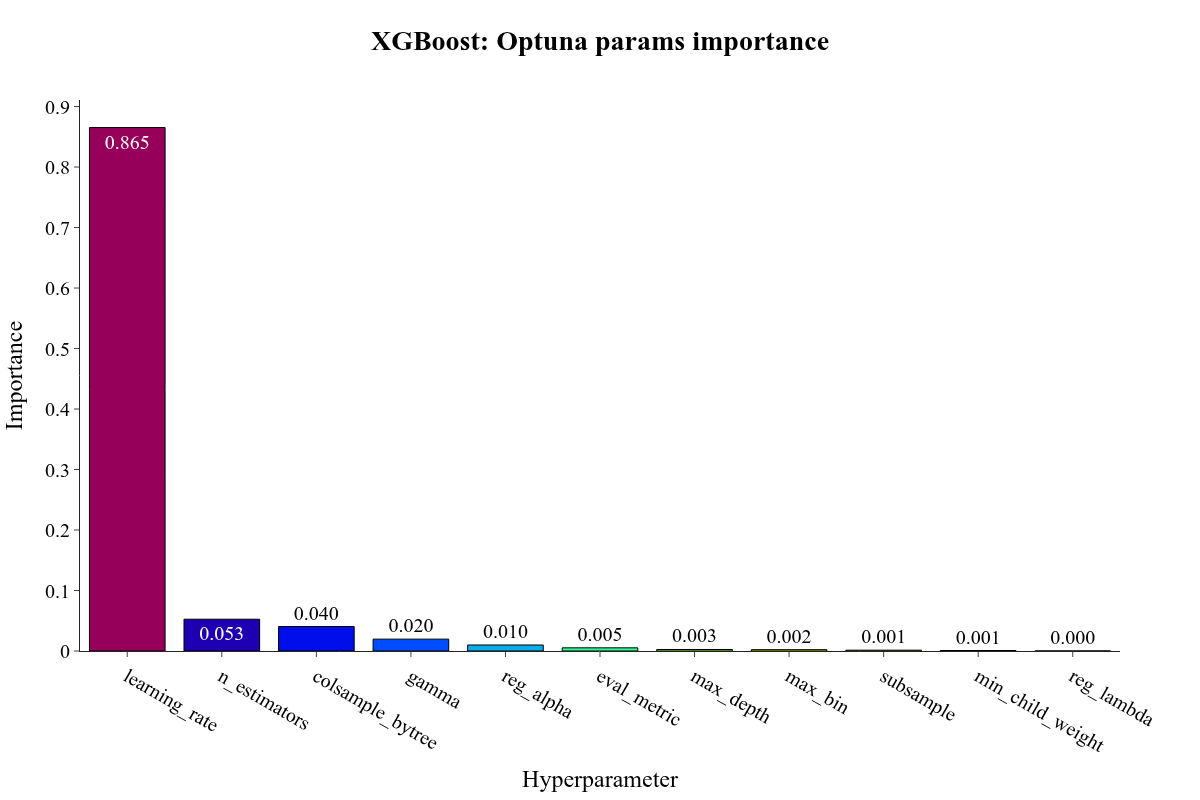

In [45]:
optuna_plots.plot_optuna_param_importance(study, plot_title="XGBoost: Optuna params importance")

In [46]:
model = XGBRegressor(**xgb_best_params)
train_scores, valid_scores, _ = cross_validation_trainer.fit(estimator=model, X=train_data[independent_features], y=train_data[target_feature])
print(f"Train {METRIC_NAME}: {np.mean(train_scores):.4f} +- {np.std(train_scores):.4f}")
print(f"Validation {METRIC_NAME}: {np.mean(valid_scores):.4f} +- {np.std(valid_scores):.4f}")

Train RMSE: 0.0557 +- 0.0001
Validation RMSE: 0.0561 +- 0.0003


## Histogram-based Gradient Boosting

In [47]:
model = HistGradientBoostingRegressor()
constant_params_grid = {
    "random_state": ("constant", [SEED]),
    "verbose": ("constant", [0]),
    "categorical_features": ("constant", [categorical_features]),
    "early_stopping": ("constant", [True]),
}
constant_params_grid["loss"] = ("constant", ["squared_error"])

min_bins = max((train_data[feature].nunique() for feature in categorical_features), default=64)
adjusted_min_bins = min_bins + (32 - min_bins % 32) if min_bins % 32 != 0 else min_bins
max_bins = 255
adjusted_max_bins = max_bins - (max_bins % 32) if max_bins % 32 != 0 else max_bins
tunable_params_grid = {
    "learning_rate": ("float", [1e-4, 0.3], {"log": True}),
    "max_iter": ("int", [200, 2000], {"step": 50}),
    "max_leaf_nodes": ("int", [15, 510], {"step": 5}),
    "max_depth": ("int", [3, 30], {"step": 1}),
    "max_features": ("float", [0.4, 1.0], {"log": False}),
    "min_samples_leaf": ("int", [5, 300], {"step": 5}),
    "l2_regularization": ("float", [1e-4, 30.0], {"log": True}),
    "max_bins": ("int", [(lambda min_bins: min_bins + (32 - min_bins % 32) if min_bins % 32 != 0 else min_bins)(max((train_data[feature].nunique() for feature in categorical_features), default=64)), (lambda max_bins: max_bins - (max_bins % 32) if max_bins % 32 != 0 else max_bins)(255)], {"step": 32}),
    "n_iter_no_change": ("int", [10, 50], {"step": 5}),
    "validation_fraction": ("float", [0.1, 0.3], {"log": False}),
}

tunable_params_grid["scoring"] = ("categorical", ["neg_root_mean_squared_error", "neg_mean_absolute_error"])

params_grid = {**constant_params_grid, **tunable_params_grid}

study = tuner.tune(model, train_data[independent_features], train_data[target_feature], params_grid)
hgbm_best_params = study.best_trial.params
constant_params = {k: v[1][0] for k, v in constant_params_grid.items()}
hgbm_best_params = {**constant_params, **hgbm_best_params}
print(hgbm_best_params)

/home/kvbiii/Programming/Python/Kaggle_Competitions/.venv/lib/python3.12/site-packages/optuna/_experimental.py:32: ExperimentalWarning:

Argument ``multivariate`` is an experimental feature. The interface can change in the future.

[I 2025-10-02 18:53:22,365] A new study created in memory with name: Optuna tuning
[I 2025-10-02 18:53:34,767] Trial 0 finished with value: 0.08084594185524939 and parameters: {'learning_rate': 0.0010582443144853525, 'max_iter': 1150, 'max_leaf_nodes': 110, 'max_depth': 4, 'max_features': 0.872191275999948, 'min_samples_leaf': 200, 'l2_regularization': 0.310298195529844, 'max_bins': 160, 'n_iter_no_change': 10, 'validation_fraction': 0.1715627208967098, 'scoring': 'neg_root_mean_squared_error'}. Best is trial 0 with value: 0.08084594185524939.
[I 2025-10-02 18:53:37,915] Trial 1 finished with value: 0.0568677120325959 and parameters: {'learning_rate': 0.10101344046742752, 'max_iter': 1800, 'max_leaf_nodes': 40, 'max_depth': 21, 'max_features': 0.731050821180

{'random_state': 17, 'verbose': 0, 'categorical_features': ['holiday', 'lighting', 'public_road', 'road_signs_present', 'road_type', 'school_season', 'time_of_day', 'weather'], 'early_stopping': True, 'loss': 'squared_error', 'learning_rate': 0.04625238653001907, 'max_iter': 950, 'max_leaf_nodes': 70, 'max_depth': 11, 'max_features': 0.8804723619221639, 'min_samples_leaf': 5, 'l2_regularization': 0.014978879561570712, 'max_bins': 160, 'n_iter_no_change': 25, 'validation_fraction': 0.271232390549363, 'scoring': 'neg_mean_absolute_error'}


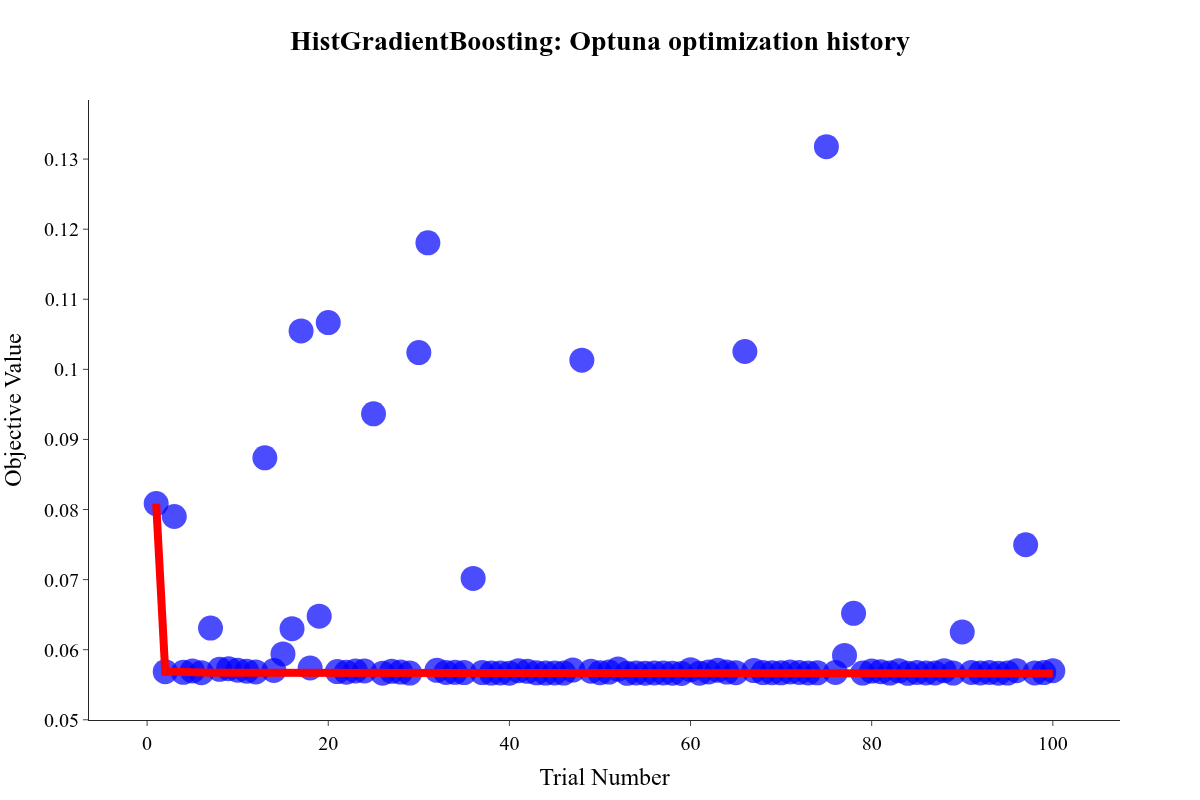

In [48]:
optuna_plots.plot_optuna_optimization_history(study, plot_title="HistGradientBoosting: Optuna optimization history", direction=METRICS[METRIC_NAME][2])

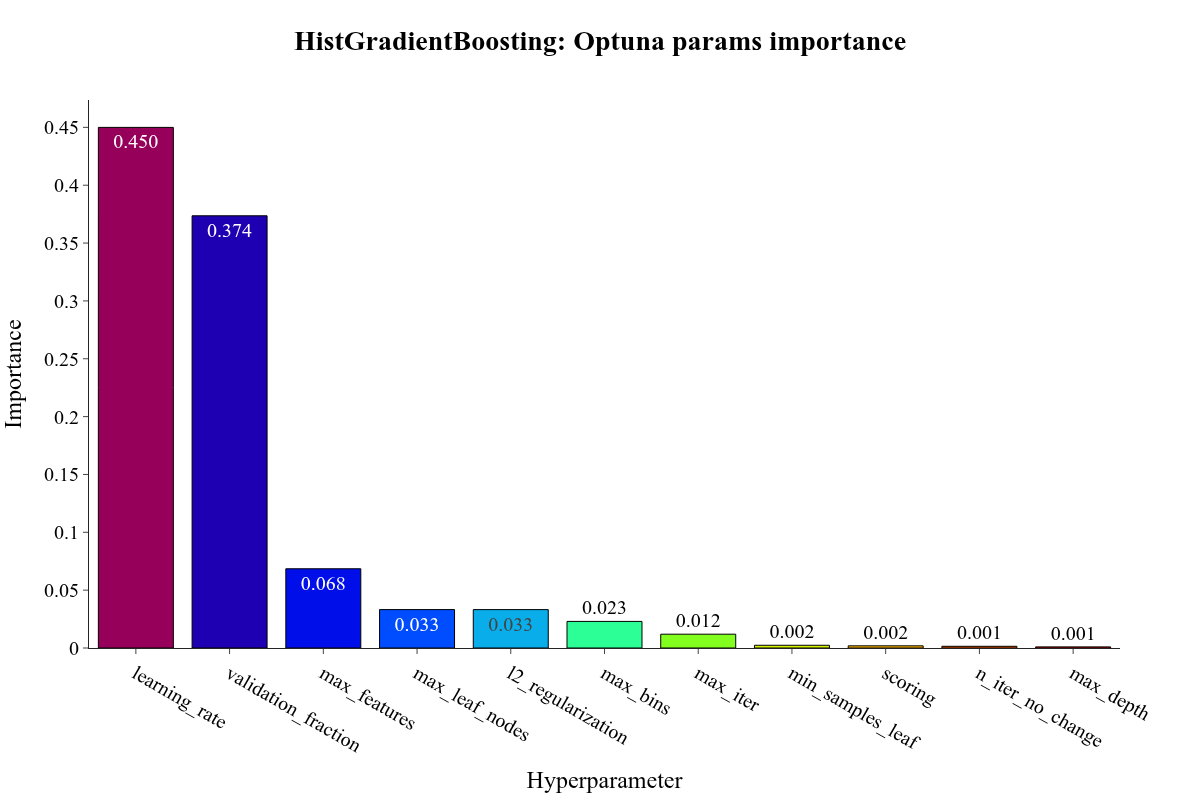

In [49]:
optuna_plots.plot_optuna_param_importance(study, plot_title="HistGradientBoosting: Optuna params importance")

In [50]:
model = HistGradientBoostingRegressor(**hgbm_best_params)
train_scores, valid_scores, _ = cross_validation_trainer.fit(estimator=model, X=train_data[independent_features], y=train_data[target_feature])
print(f"Train {METRIC_NAME}: {np.mean(train_scores):.4f} +- {np.std(train_scores):.4f}")
print(f"Validation {METRIC_NAME}: {np.mean(valid_scores):.4f} +- {np.std(valid_scores):.4f}")

Train RMSE: 0.0555 +- 0.0001
Validation RMSE: 0.0561 +- 0.0003


## Catboost

In [51]:
model = CatBoostRegressor()
constant_params_grid = {
    "random_state": ("constant", [SEED]),
    "verbose": ("constant", [0]),
    "cat_features": ("constant", [categorical_features]),
    "task_type": ("constant", ["GPU"]),
    "allow_writing_files": ("constant", [False]),
    "thread_count": ("constant", [-1]),
    "early_stopping_rounds": ("constant", [100]),
}
constant_params_grid["loss_function"] = ("constant", ["RMSE"])

tunable_params_grid = {
    "iterations": ("int", [50, 2000], {"step": 50}),
    "learning_rate": ("float", [1e-3, 0.3], {"log": True}),
    "depth": ("int", [3, 10], {"step": 1}),
    "l2_leaf_reg": ("float", [1e-3, 30], {"log": True}),
    "random_strength": ("float", [1e-3, 10.0], {"log": True}),
    "bagging_temperature": ("float", [0.3, 1.0], {"log": True}),
    "min_data_in_leaf": ("int", [1, 296], {"step": 5}),
    "max_bin": ("int", [32, 480], {"step": 32}),
}
tunable_params_grid["eval_metric"] = ("categorical", ["RMSE"])

params_grid = {**constant_params_grid, **tunable_params_grid}

study = tuner.tune(model, train_data[independent_features], train_data[target_feature], params_grid)
catboost_best_params = study.best_trial.params
constant_params = {k: v[1][0] for k, v in constant_params_grid.items()}
catboost_best_params = {**constant_params, **catboost_best_params}
print(catboost_best_params)

/home/kvbiii/Programming/Python/Kaggle_Competitions/.venv/lib/python3.12/site-packages/optuna/_experimental.py:32: ExperimentalWarning:

Argument ``multivariate`` is an experimental feature. The interface can change in the future.

[I 2025-10-02 19:40:31,698] A new study created in memory with name: Optuna tuning
[I 2025-10-02 19:41:04,591] Trial 0 finished with value: 0.05702279194790603 and parameters: {'iterations': 600, 'learning_rate': 0.0206218550445619, 'depth': 4, 'l2_leaf_reg': 0.00201371561093265, 'random_strength': 1.4058592411732862, 'bagging_temperature': 0.6611562428979949, 'min_data_in_leaf': 191, 'max_bin': 288, 'eval_metric': 'RMSE'}. Best is trial 0 with value: 0.05702279194790603.
[I 2025-10-02 19:41:11,811] Trial 1 finished with value: 0.10908252312436431 and parameters: {'iterations': 100, 'learning_rate': 0.007697464327022002, 'depth': 10, 'l2_leaf_reg': 0.0018570658959306857, 'random_strength': 2.8586988975615437, 'bagging_temperature': 0.8626563515456908, 'min_d

{'random_state': 17, 'verbose': 0, 'cat_features': ['holiday', 'lighting', 'public_road', 'road_signs_present', 'road_type', 'school_season', 'time_of_day', 'weather'], 'task_type': 'GPU', 'allow_writing_files': False, 'thread_count': -1, 'early_stopping_rounds': 100, 'loss_function': 'RMSE', 'iterations': 1100, 'learning_rate': 0.03136781659330664, 'depth': 7, 'l2_leaf_reg': 0.9054584420246654, 'random_strength': 0.042384695716525776, 'bagging_temperature': 0.5741563233173266, 'min_data_in_leaf': 61, 'max_bin': 224, 'eval_metric': 'RMSE'}


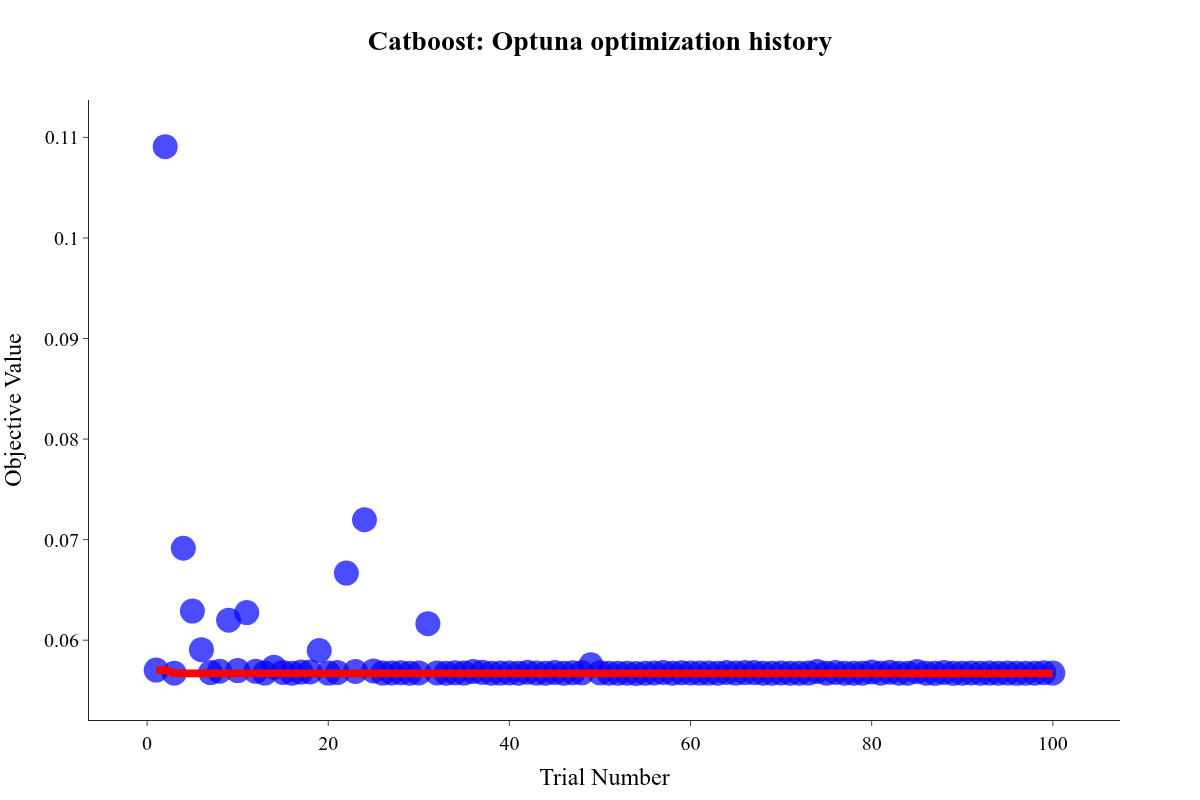

In [52]:
optuna_plots.plot_optuna_optimization_history(study, plot_title="Catboost: Optuna optimization history", direction=METRICS[METRIC_NAME][2])

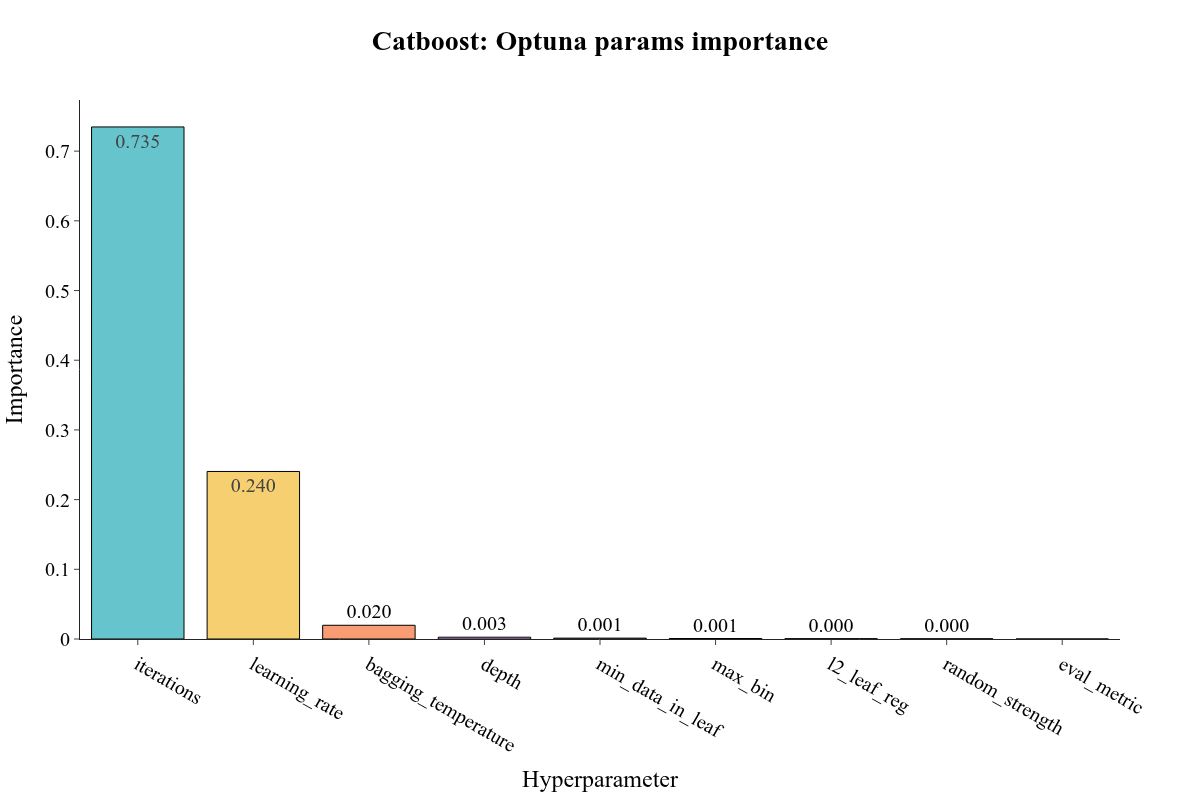

In [53]:
optuna_plots.plot_optuna_param_importance(study, plot_title="Catboost: Optuna params importance")

In [54]:
model = CatBoostRegressor(**catboost_best_params)
train_scores, valid_scores, _ = cross_validation_trainer.fit(estimator=model, X=train_data[independent_features], y=train_data[target_feature])
print(f"Train {METRIC_NAME}: {np.mean(train_scores):.4f} +- {np.std(train_scores):.4f}")
print(f"Validation {METRIC_NAME}: {np.mean(valid_scores):.4f} +- {np.std(valid_scores):.4f}")

Train RMSE: 0.0558 +- 0.0001
Validation RMSE: 0.0562 +- 0.0003


## Ensemble weights tuning

In [55]:
# estimators = [
#     LGBMRegressor(**{'boosting_type': 'gbdt', 'seed': 17, 'verbose': -1, 'n_jobs': -1, 'early_stopping_rounds': 100, 'objective': 'regression', 'n_estimators': 1800, 'learning_rate': 0.009941210322039071, 'num_leaves': 123, 'max_depth': 11, 'min_child_samples': 30, 'subsample': 0.8232670624065063, 'colsample_bytree': 0.5031846332954723, 'reg_alpha': 0.03275591812630481, 'reg_lambda': 0.00010019176274082355, 'min_split_gain': 0.0008568126350491756, 'bagging_freq': 4, 'max_bin': 319, 'metric': 'l1'}),
#     LGBMRegressor(**{'boosting_type': 'goss', 'seed': 17, 'verbose': -1, 'n_jobs': -1, 'early_stopping_rounds': 100, 'objective': 'regression', 'n_estimators': 1950, 'learning_rate': 0.015696979538312263, 'num_leaves': 331, 'max_depth': 5, 'min_child_samples': 15, 'subsample': 0.45029110679946144, 'colsample_bytree': 0.48404518214219056, 'reg_alpha': 0.003050254012394828, 'reg_lambda': 0.00017039989970268836, 'min_split_gain': 0.0001556876241786222, 'max_bin': 351, 'metric': 'l1'}),
#     XGBRegressor(**{'seed': 17, 'verbosity': 0, 'n_jobs': -1, 'tree_method': 'hist', 'enable_categorical': True, 'early_stopping_rounds': 100, 'objective': 'reg:squarederror', 'n_estimators': 1700, 'learning_rate': 0.00875365849000294, 'max_depth': 28, 'min_child_weight': 36, 'subsample': 0.889976714961396, 'colsample_bytree': 0.4558119852430597, 'gamma': 0.0006787172766288, 'reg_alpha': 0.0007324143169087691, 'reg_lambda': 0.007735709161449897, 'max_bin': 415, 'eval_metric': 'mae'}),
#     HistGradientBoostingRegressor(**hgbm_best_params),
#     CatBoostRegressor(random_state=SEED, verbose=0, cat_features=categorical_features, task_type='GPU', loss_function='RMSE', eval_metric='RMSE', early_stopping_rounds=100, allow_writing_files=False)
# ]

estimators = [
    LGBMRegressor(**lgbm_best_params),
    LGBMRegressor(**lgbm_goss_best_params),
    XGBRegressor(**xgb_best_params),
    HistGradientBoostingRegressor(**hgbm_best_params),
    CatBoostRegressor(**catboost_best_params)
]

ensemble_weights_tuner = EnsembleWeightTunerCV(
    estimators = estimators,
    cross_validator = cross_validation_trainer,
    n_trials = N_TRIALS*5,
    seed = SEED,
    allow_negative_weights = True,
)
ensemble_weights_tuner.tune(train_data[independent_features], train_data[target_feature])
best_weights = ensemble_weights_tuner.best_weights
for i, estimator in enumerate(ensemble_weights_tuner.estimators):
    print(f"Estimator {i}: {estimator.__class__.__name__}, Weight: {best_weights[i]:.4f}")

/home/kvbiii/Programming/Python/Kaggle_Competitions/.venv/lib/python3.12/site-packages/optuna/_experimental.py:32: ExperimentalWarning:

Argument ``multivariate`` is an experimental feature. The interface can change in the future.

[I 2025-10-02 22:16:20,170] A new study created in memory with name: Ensemble weight tuning
[I 2025-10-02 22:16:20,187] Trial 0 finished with value: 0.5801262579392037 and parameters: {'w0': -0.4106699946257806, 'w1': 0.06117351121058823, 'w2': -0.6169584261050103, 'w3': -0.8641992836174173, 'w4': 0.5739709199998266}. Best is trial 0 with value: 0.5801262579392037.
[I 2025-10-02 22:16:20,195] Trial 1 finished with value: 0.48162070736959306 and parameters: {'w0': 0.31266704355171093, 'w1': 0.27504179208727164, 'w2': 0.15120578750606795, 'w3': -0.921874167622267, 'w4': -0.28437279103290214}. Best is trial 1 with value: 0.48162070736959306.
[I 2025-10-02 22:16:20,207] Trial 2 finished with value: 0.3350303144889177 and parameters: {'w0': 0.8913663736368151, 'w

Estimator 0: LGBMRegressor, Weight: 0.2156
Estimator 1: LGBMRegressor, Weight: 0.3314
Estimator 2: XGBRegressor, Weight: 0.3234
Estimator 3: HistGradientBoostingRegressor, Weight: 0.1246
Estimator 4: CatBoostRegressor, Weight: 0.0049


In [56]:
ensemble_model = EnsembleModel(estimators=ensemble_weights_tuner.estimators, problem_type=PROBLEM_TYPE, weights=ensemble_weights_tuner.best_weights)
train_scores, valid_scores, _ = cross_validation_trainer.fit(estimator=ensemble_model, X=train_data[independent_features], y=train_data[target_feature])
print(f"Train {METRIC_NAME}: {np.mean(train_scores):.4f} +- {np.std(train_scores):.4f}")
print(f"Validation {METRIC_NAME}: {np.mean(valid_scores):.4f} +- {np.std(valid_scores):.4f}")

Train RMSE: 0.0556 +- 0.0001
Validation RMSE: 0.0560 +- 0.0003


In [57]:
final_model = ensemble_model

# Evaluation

In [58]:
train_data_temp, test_data_temp = train_test_split(train_data, test_size=0.2, random_state=SEED, shuffle=True, stratify=train_data[target_feature])

In [59]:
final_model.fit(train_data_temp[independent_features], train_data_temp[target_feature], eval_set=[(test_data_temp[independent_features], test_data_temp[target_feature])])

y_train = train_data_temp[target_feature]
y_train_pred = final_model.predict(train_data_temp[independent_features])

y_test = test_data_temp[target_feature]
y_test_pred = final_model.predict(test_data_temp[independent_features])

In [60]:
regression_results(y_train_true=y_train, y_train_pred=y_train_pred, y_test_true=y_test, y_test_pred=y_test_pred)

,MAE,MedAE,MSE,RMSE,MAPE,R²
Train,0.0432,0.0358,0.0031,0.0555,113007450277462.97%,0.8887
Test,0.0436,0.0360,0.0032,0.0562,113094251077647.41%,0.8860


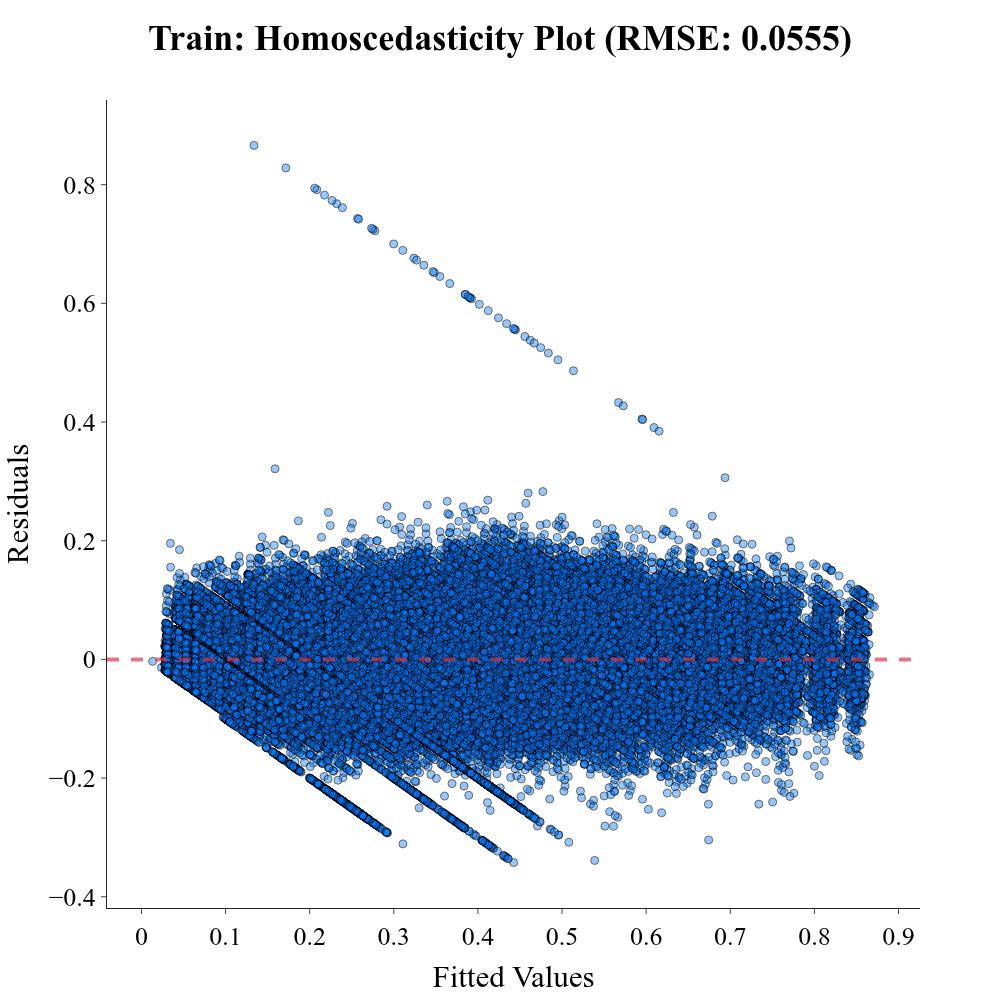

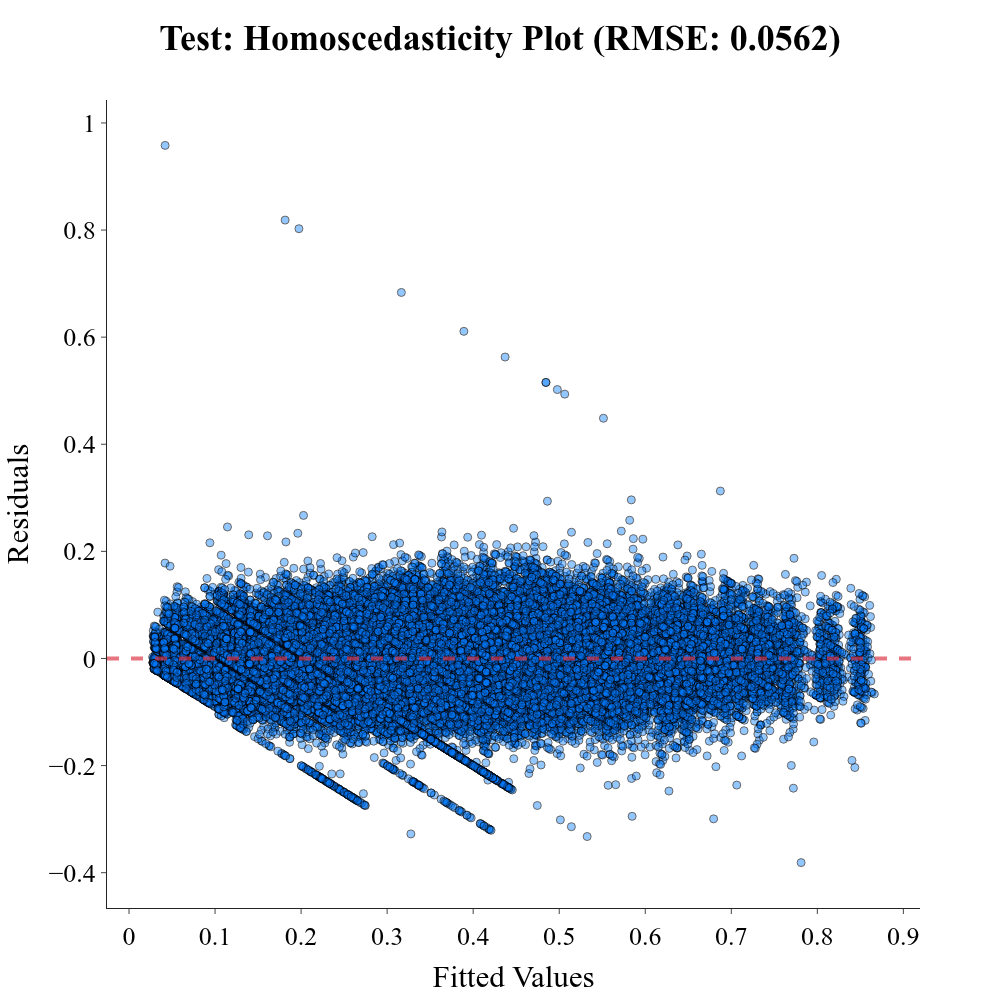

In [61]:
regression_plots.homoscedacity_plot(y_true=y_train, y_pred=y_train_pred, plot_title=f"Train: Homoscedasticity Plot", metric_name="RMSE")
regression_plots.homoscedacity_plot(y_true=y_test, y_pred=y_test_pred, plot_title=f"Test: Homoscedasticity Plot", metric_name="RMSE")

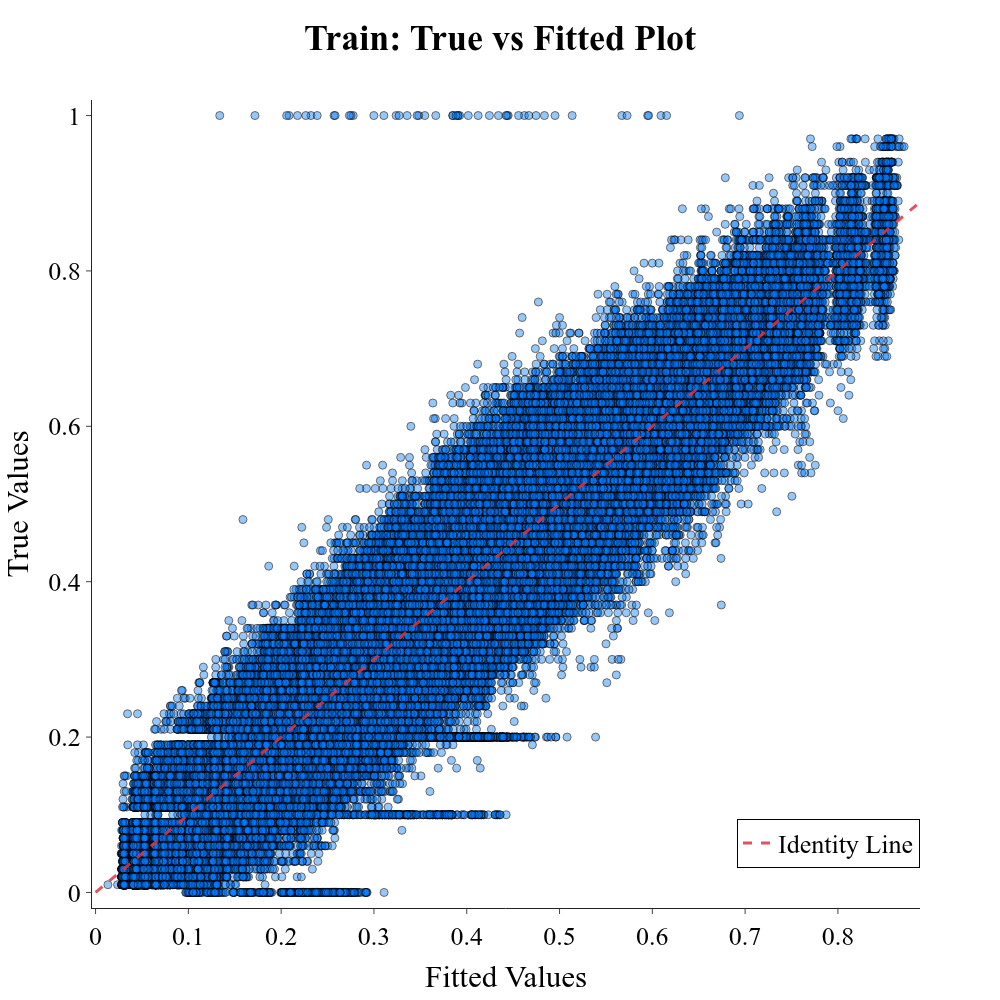

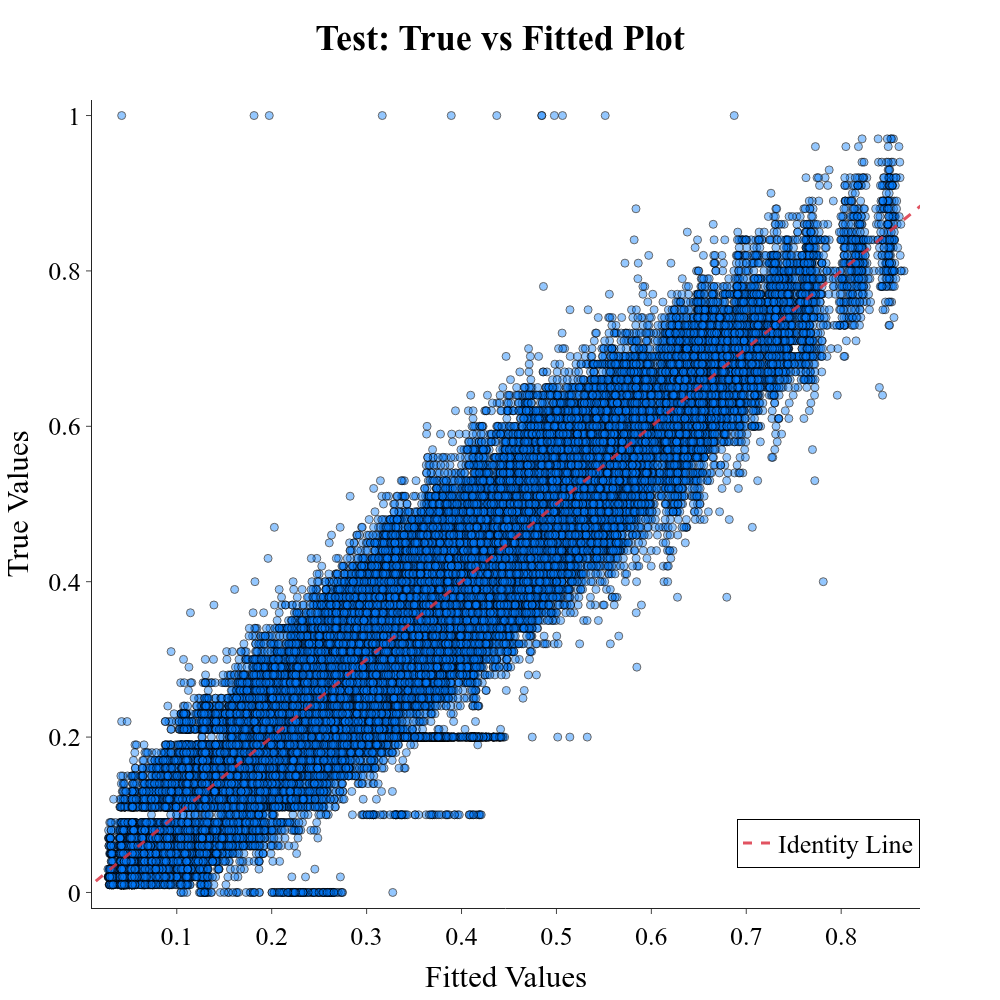

In [62]:
regression_plots.true_vs_fitted_plot(y_true=y_train, y_pred=y_train_pred, plot_title=f"Train: True vs Fitted Plot", metric_name="RMSE")
regression_plots.true_vs_fitted_plot(y_true=y_test, y_pred=y_test_pred, plot_title=f"Test: True vs Fitted Plot", metric_name="RMSE")

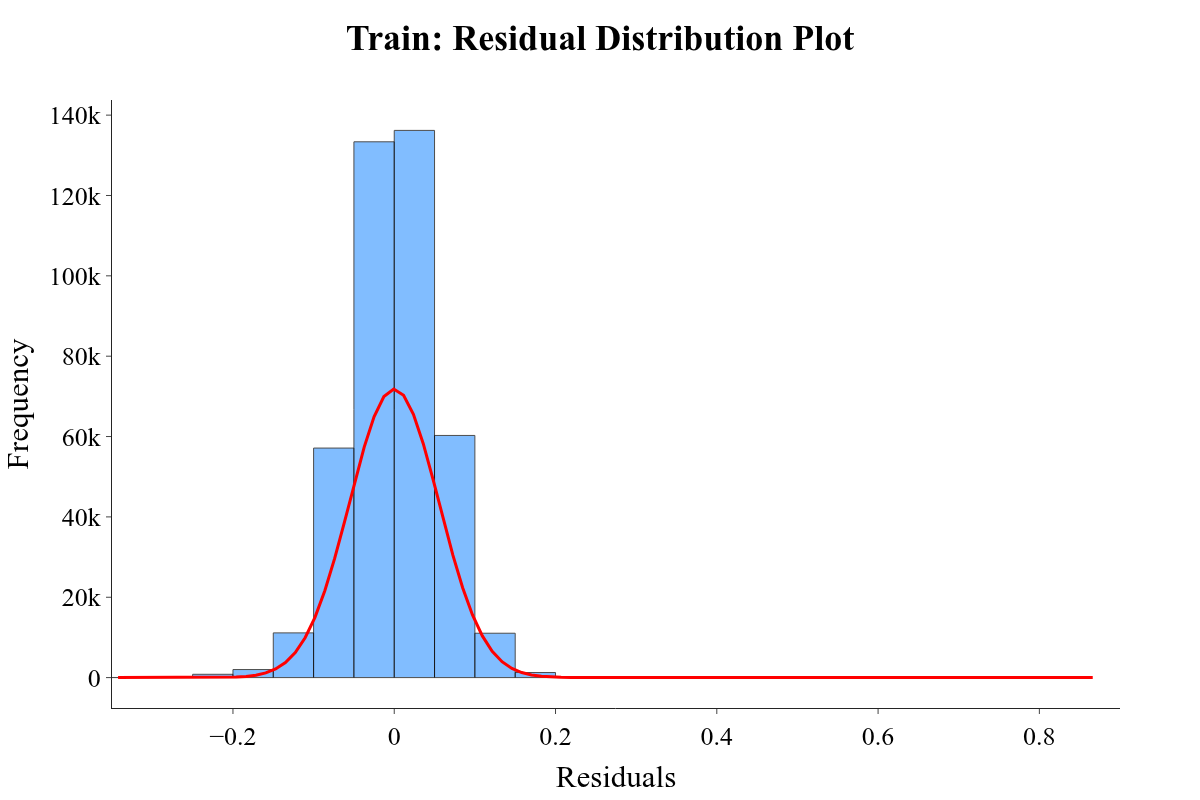

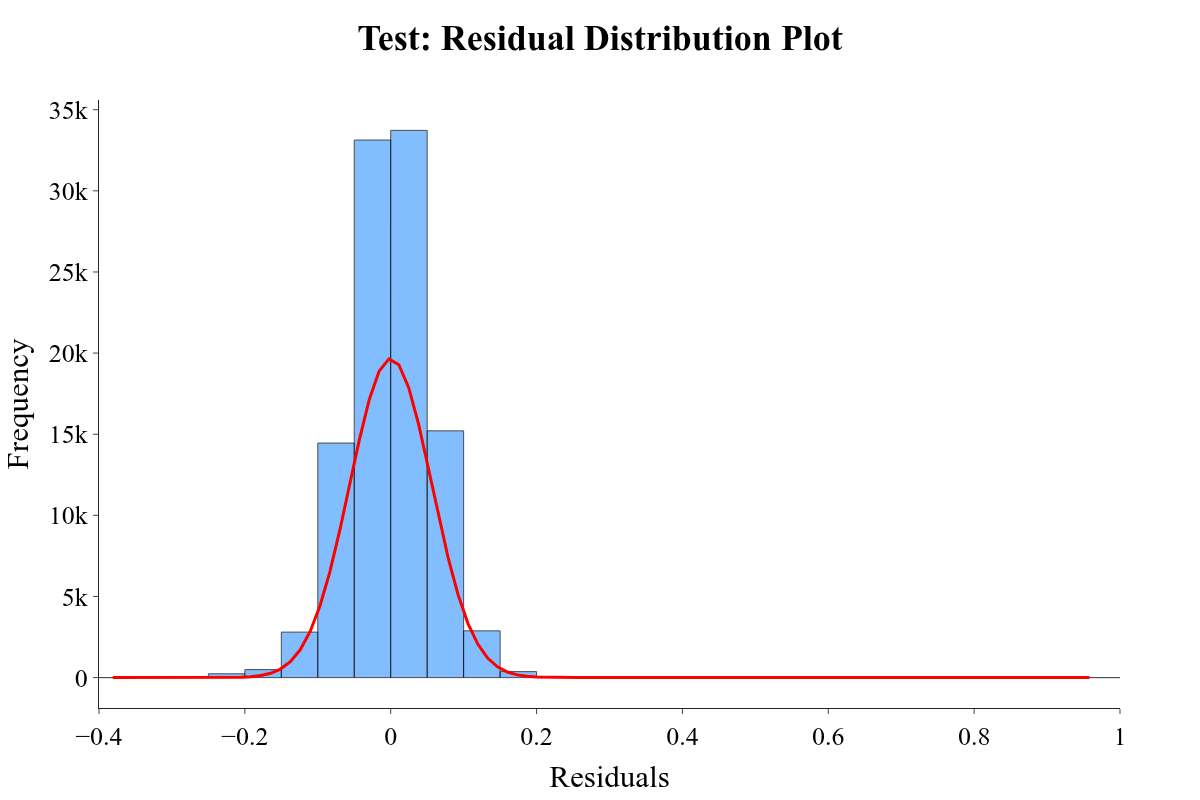

In [63]:
regression_plots.residual_distribution_plot(y_true=y_train, y_pred=y_train_pred, plot_title=f"Train: Residual Distribution Plot", metric_name="RMSE")
regression_plots.residual_distribution_plot(y_true=y_test, y_pred=y_test_pred, plot_title=f"Test: Residual Distribution Plot", metric_name="RMSE")

## Submission (traditional approach)

In [65]:
ensemble_model = EnsembleModel(estimators=ensemble_weights_tuner.estimators, problem_type=PROBLEM_TYPE, weights=ensemble_weights_tuner.best_weights)
final_model = deepcopy(ensemble_model)

In [66]:
final_model_no_early_stopping = deepcopy(final_model)
for idx, estimator in enumerate(final_model_no_early_stopping.estimators):
    if hasattr(estimator, 'early_stopping_rounds'):
        final_model_no_early_stopping.estimators[idx].set_params(early_stopping_rounds=None)
final_model_no_early_stopping.fit(train_data[independent_features], train_data[target_feature])
submission = pd.read_csv("input/sample_submission.csv")
submission[target_feature] = final_model_no_early_stopping.predict(test_data[independent_features])
submission.to_csv("submission.csv", index=False)
submission.head()

,id,accident_risk
0,517754,0.294671
1,517755,0.122888
2,517756,0.183551
3,517757,0.318746
4,517758,0.405091


## Submission (validation set approach)

In [67]:
ensemble_model = EnsembleModel(estimators=ensemble_weights_tuner.estimators, problem_type=PROBLEM_TYPE, weights=ensemble_weights_tuner.best_weights)
final_model = deepcopy(ensemble_model)

In [68]:
final_model.fit(train_data_temp[independent_features], train_data_temp[target_feature], eval_set=[(test_data_temp[independent_features], test_data_temp[target_feature])])
submission = pd.read_csv("input/sample_submission.csv")
submission[target_feature] = final_model.predict(test_data[independent_features])
submission.to_csv("submission.csv", index=False)
submission.head()

,id,accident_risk
0,517754,0.292993
1,517755,0.121315
2,517756,0.183966
3,517757,0.319465
4,517758,0.404002


## Submission (OOF approach)

In [69]:
ensemble_model = EnsembleModel(estimators=ensemble_weights_tuner.estimators, problem_type=PROBLEM_TYPE, weights=ensemble_weights_tuner.best_weights)
final_model = deepcopy(ensemble_model)

In [70]:
train_scores, valid_scores, avg_test_pred = cross_validation_trainer.fit(estimator=deepcopy(final_model), X=train_data[independent_features], y=train_data[target_feature], X_test=test_data[independent_features])
print(f"Train {METRIC_NAME}: {np.mean(train_scores):.4f} +- {np.std(train_scores):.4f}")
print(f"Validation {METRIC_NAME}: {np.mean(valid_scores):.4f} +- {np.std(valid_scores):.4f}")
submission = pd.read_csv("input/sample_submission.csv")
submission[target_feature] = avg_test_pred
submission[target_feature] = submission[target_feature].clip(lower=train_data[target_feature].min(), upper=train_data[target_feature].max())
submission.to_csv("submission.csv", index=False)
submission.head()

Train RMSE: 0.0556 +- 0.0001
Validation RMSE: 0.0560 +- 0.0003


,id,accident_risk
0,517754,0.294006
1,517755,0.123311
2,517756,0.183762
3,517757,0.319355
4,517758,0.405556
